# WebUI-7k Dataset Exploration Notebook
## UI Element Detection for Web Pages

This notebook explores the WebUI-7k dataset to understand its structure, analyze UI element distributions, and determine optimal training strategies for YOLO v11 object detection.

### Dataset Overview
- **WebUI-7k**: 7,000 web pages for UI element detection
- **Source**: biglab/webui-7k (HuggingFace)
- **Purpose**: Training models to detect UI elements like buttons, text fields, links, images, etc.

### Hardware Configuration
- **CPU**: Intel i5-12450H
- **GPU**: RTX 3050 Mobile (4GB VRAM)
- **Environment**: Conda env 'WEBUI' with TensorFlow + YOLO v11

## 1. Environment Setup (Already Completed)

The conda environment 'WEBUI' has been created with the following packages:
- TensorFlow
- Ultralytics (YOLO v11)
- OpenCV, Matplotlib, Seaborn, Pandas, NumPy, Pillow

To activate the environment:
```bash
conda activate WEBUI
```

## 2. Import Required Libraries

In [1]:
import os
import json
import gzip
import glob
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 3. Load Dataset Metadata and Define Paths

In [2]:
# Define dataset paths
BASE_PATH = "/mnt/c/WebUIDetection/webui-7k"
DATASET_PATH = os.path.join(BASE_PATH, "train_split_web7k")
MANIFEST_PATH = os.path.join(BASE_PATH, "train_split_web7k.json")

# Check if dataset is extracted
if not os.path.exists(DATASET_PATH):
    print("⚠️ Dataset not extracted yet!")
    print("The dataset appears to be in split zip files. Please extract them first:")
    print("   1. Combine the split files: cat train_split_web7k.zip-* > train_split_web7k.zip")
    print("   2. Extract: unzip train_split_web7k.zip")
    print(f"\nExpected path: {DATASET_PATH}")
else:
    # Load the manifest file
    with open(MANIFEST_PATH, 'r') as f:
        sample_ids = json.load(f)

    print(f"📁 Dataset Base Path: {BASE_PATH}")
    print(f"📂 Dataset Folder: {DATASET_PATH}")
    print(f"📋 Total samples in manifest: {len(sample_ids)}")
    print(f"\n🔢 First 10 sample IDs: {sample_ids[:10]}")

📁 Dataset Base Path: /mnt/c/WebUIDetection/webui-7k
📂 Dataset Folder: /mnt/c/WebUIDetection/webui-7k/train_split_web7k
📋 Total samples in manifest: 7000

🔢 First 10 sample IDs: ['1656100510688', '1655891768961', '1656063672586', '1655992270389', '1656236624102', '1656181976651', '1656160184754', '1656083589609', '1656161837476', '1656347386665']


## 4. Explore Dataset Structure

Let's examine the folder structure and understand what files are available for each sample.

In [3]:
# Count actual folders in the dataset directory
sample_folders = [f for f in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, f))]
print(f"📂 Total sample folders found: {len(sample_folders)}")

# Examine the structure of one sample folder
sample_folder = os.path.join(DATASET_PATH, sample_folders[0])
sample_files = os.listdir(sample_folder)

print(f"\n📁 Sample folder: {sample_folders[0]}")
print(f"📄 Files in sample folder ({len(sample_files)} files):")
for f in sorted(sample_files):
    file_path = os.path.join(sample_folder, f)
    size = os.path.getsize(file_path) / 1024  # KB
    print(f"   - {f} ({size:.1f} KB)")

📂 Total sample folders found: 6919

📁 Sample folder: 1655885421832
📄 Files in sample folder (18 files):
   - default_1366-768-axtree.json.gz (45.6 KB)
   - default_1366-768-screenshot-full.webp (120.3 KB)
   - default_1366-768-screenshot.webp (55.1 KB)
   - default_1920-1080-axtree.json.gz (45.5 KB)
   - default_1920-1080-bb.json.gz (15.2 KB)
   - default_1920-1080-box.json.gz (50.0 KB)
   - default_1920-1080-class.json.gz (8.5 KB)
   - default_1920-1080-html.html (114.7 KB)
   - default_1920-1080-links.json (0.0 KB)
   - default_1920-1080-screenshot-full.webp (129.8 KB)
   - default_1920-1080-screenshot.webp (86.5 KB)
   - default_1920-1080-screenshot_1.webp (86.5 KB)
   - default_1920-1080-style.json.gz (272.1 KB)
   - default_1920-1080-style.json_1.gz (272.1 KB)
   - default_1920-1080-url.txt (0.0 KB)
   - default_1920-1080-url_1.txt (0.0 KB)
   - default_1920-1080-viewport.json.gz (5.3 KB)
   - default_1920-1080-viewport.json_1.gz (5.3 KB)


In [4]:
# Helper functions to load gzipped JSON files
def load_gzip_json(filepath):
    """Load a gzip-compressed JSON file."""
    with gzip.open(filepath, 'rt', encoding='utf-8') as f:
        return json.load(f)

def get_sample_data(sample_id, resolution="1920-1080"):
    """Load all relevant data for a sample."""
    sample_path = os.path.join(DATASET_PATH, sample_id)
    
    data = {}
    
    # Load bounding boxes
    bb_file = os.path.join(sample_path, f"default_{resolution}-bb.json.gz")
    if os.path.exists(bb_file):
        data['bboxes'] = load_gzip_json(bb_file)
    
    # Load class labels
    class_file = os.path.join(sample_path, f"default_{resolution}-class.json.gz")
    if os.path.exists(class_file):
        data['classes'] = load_gzip_json(class_file)
    
    # Get screenshot path
    screenshot_file = os.path.join(sample_path, f"default_{resolution}-screenshot.webp")
    if os.path.exists(screenshot_file):
        data['screenshot_path'] = screenshot_file
    
    # Full screenshot
    full_screenshot = os.path.join(sample_path, f"default_{resolution}-screenshot-full.webp")
    if os.path.exists(full_screenshot):
        data['full_screenshot_path'] = full_screenshot
    
    return data

# Test loading a sample
test_sample = sample_folders[0]
sample_data = get_sample_data(test_sample)
print(f"✅ Successfully loaded sample: {test_sample}")
print(f"📦 Available data keys: {list(sample_data.keys())}")

✅ Successfully loaded sample: 1655885421832
📦 Available data keys: ['bboxes', 'classes', 'screenshot_path', 'full_screenshot_path']


In [5]:
# Examine the annotation format
print("📋 BOUNDING BOX ANNOTATIONS FORMAT:")
print("-" * 50)
bboxes = sample_data.get('bboxes', {})
# Show first 10 bounding boxes
for idx, (key, bbox) in enumerate(list(bboxes.items())[:10]):
    if bbox is not None:
        print(f"Element {key}: {bbox}")
    else:
        print(f"Element {key}: None (no visible bbox)")

print(f"\n📊 Total elements with bboxes: {len([b for b in bboxes.values() if b is not None])}")
print(f"📊 Total elements with null bboxes: {len([b for b in bboxes.values() if b is None])}")

📋 BOUNDING BOX ANNOTATIONS FORMAT:
--------------------------------------------------
Element 3: {'x': 0, 'y': 0, 'width': 1920, 'height': 1080}
Element 4: {'x': 0, 'y': 45, 'width': 1920, 'height': 1584.375}
Element 5: {'x': 320.625, 'y': 18.984375, 'width': 10.0625, 'height': 5.03125}
Element 7: {'x': 506.75, 'y': 0, 'width': 98.0625, 'height': 44}
Element 8: {'x': 514.75, 'y': 8, 'width': 82.0625, 'height': 28}
Element 9: {'x': 514.75, 'y': 8, 'width': 82.0625, 'height': 28}
Element 10: {'x': 518.75, 'y': 12, 'width': 56, 'height': 20}
Element 11: {'x': 582.75, 'y': 18.984375, 'width': 10.0625, 'height': 5.03125}
Element 12: {'x': 604.8125, 'y': 7, 'width': 1238.1875, 'height': 30}
Element 13: {'x': 224.625, 'y': 0, 'width': 380.1875, 'height': 44}

📊 Total elements with bboxes: 1657
📊 Total elements with null bboxes: 872


In [6]:
# Examine class labels format
print("🏷️ CLASS LABELS FORMAT:")
print("-" * 50)
classes = sample_data.get('classes', {})
# Show first 20 class entries
for idx, (key, cls) in enumerate(list(classes.items())[:20]):
    print(f"Element {key}: {cls}")

# Extract unique class names from this sample
all_class_names = set()
for element_classes in classes.values():
    if isinstance(element_classes, dict):
        all_class_names.update(element_classes.values())

print(f"\n🎯 Unique classes in this sample: {len(all_class_names)}")
print(f"📝 Sample classes: {list(all_class_names)[:15]}...")

🏷️ CLASS LABELS FORMAT:
--------------------------------------------------
Element 4: {}
Element 5: {'0': 'downArrow'}
Element 7: {}
Element 8: {'0': 'dropdown-trigger'}
Element 9: {}
Element 10: {'0': 'linksTitle'}
Element 11: {'0': 'downArrow'}
Element 12: {'0': 'rightItems'}
Element 13: {'0': 'links'}
Element 14: {}
Element 15: {'0': 'dropdown-trigger'}
Element 16: {}
Element 17: {'0': 'linksTitle'}
Element 18: {'0': 'feedbackButton'}
Element 19: {}
Element 20: {'0': 'titleText'}
Element 21: {}
Element 22: {}
Element 23: {}
Element 24: {}

🎯 Unique classes in this sample: 193
📝 Sample classes: ['vote-chip', 'patchset', 'dateContainer', 'loginButton', 'reviewer-row', 'linksTitle', 'sizeBars', 'headerTitle', 'separatedSection', 'stats', 'hidden', 'patchInfoContent', 'fullFileName', 'patchInfo-header', 'max']...


## 5. Analyze UI Element Class Distribution

Let's extract all unique UI element classes from multiple samples and analyze their distribution.

In [7]:
# Analyze class distribution across a subset of samples (for speed)
NUM_SAMPLES_TO_ANALYZE = min(500, len(sample_folders))
sample_subset = random.sample(sample_folders, NUM_SAMPLES_TO_ANALYZE)

all_classes = Counter()
elements_per_sample = []
valid_bboxes_per_sample = []

print(f"🔍 Analyzing {NUM_SAMPLES_TO_ANALYZE} samples...")

for i, sample_id in enumerate(sample_subset):
    if (i + 1) % 100 == 0:
        print(f"   Processed {i+1}/{NUM_SAMPLES_TO_ANALYZE} samples...")
    
    try:
        data = get_sample_data(sample_id)
        classes = data.get('classes', {})
        bboxes = data.get('bboxes', {})
        
        # Count valid bboxes
        valid_bboxes = len([b for b in bboxes.values() if b is not None])
        valid_bboxes_per_sample.append(valid_bboxes)
        
        # Extract class names
        sample_classes = []
        for element_classes in classes.values():
            if isinstance(element_classes, dict):
                sample_classes.extend(element_classes.values())
        
        all_classes.update(sample_classes)
        elements_per_sample.append(len(sample_classes))
    except Exception as e:
        print(f"   ⚠️ Error processing {sample_id}: {e}")

print(f"\n✅ Analysis complete!")
print(f"📊 Total unique class names found: {len(all_classes)}")
print(f"📊 Total class occurrences: {sum(all_classes.values())}")

🔍 Analyzing 500 samples...
   Processed 100/500 samples...
   Processed 200/500 samples...
   Processed 300/500 samples...
   Processed 400/500 samples...
   Processed 500/500 samples...

✅ Analysis complete!
📊 Total unique class names found: 32886
📊 Total class occurrences: 203330


In [8]:
# Create DataFrame for class distribution
class_df = pd.DataFrame(all_classes.most_common(), columns=['Class', 'Count'])
class_df['Percentage'] = (class_df['Count'] / class_df['Count'].sum() * 100).round(2)

print("📊 TOP 30 MOST COMMON UI ELEMENT CLASSES:")
print("=" * 60)
print(class_df.head(30).to_string(index=False))

print(f"\n📊 Total unique classes: {len(class_df)}")
print(f"📊 Classes with < 10 occurrences: {len(class_df[class_df['Count'] < 10])}")

📊 TOP 30 MOST COMMON UI ELEMENT CLASSES:
                   Class  Count  Percentage
               menu-item   2316        1.14
                      fa   1243        0.61
menu-item-type-post_type   1194        0.59
   menu-item-object-page   1167        0.57
                clearfix   1106        0.54
               container    874        0.43
                    icon    808        0.40
                     row    782        0.38
                    flex    723        0.36
                     btn    714        0.35
      screen-reader-text    588        0.29
                 rpwe-li    565        0.28
           rpwe-clearfix    565        0.28
              rpwe-title    565        0.28
                   block    556        0.27
                 content    487        0.24
               thumbnail    476        0.23
                   title    466        0.23
                  w-full    457        0.22
                   thumb    455        0.22
       elementor-element    433    

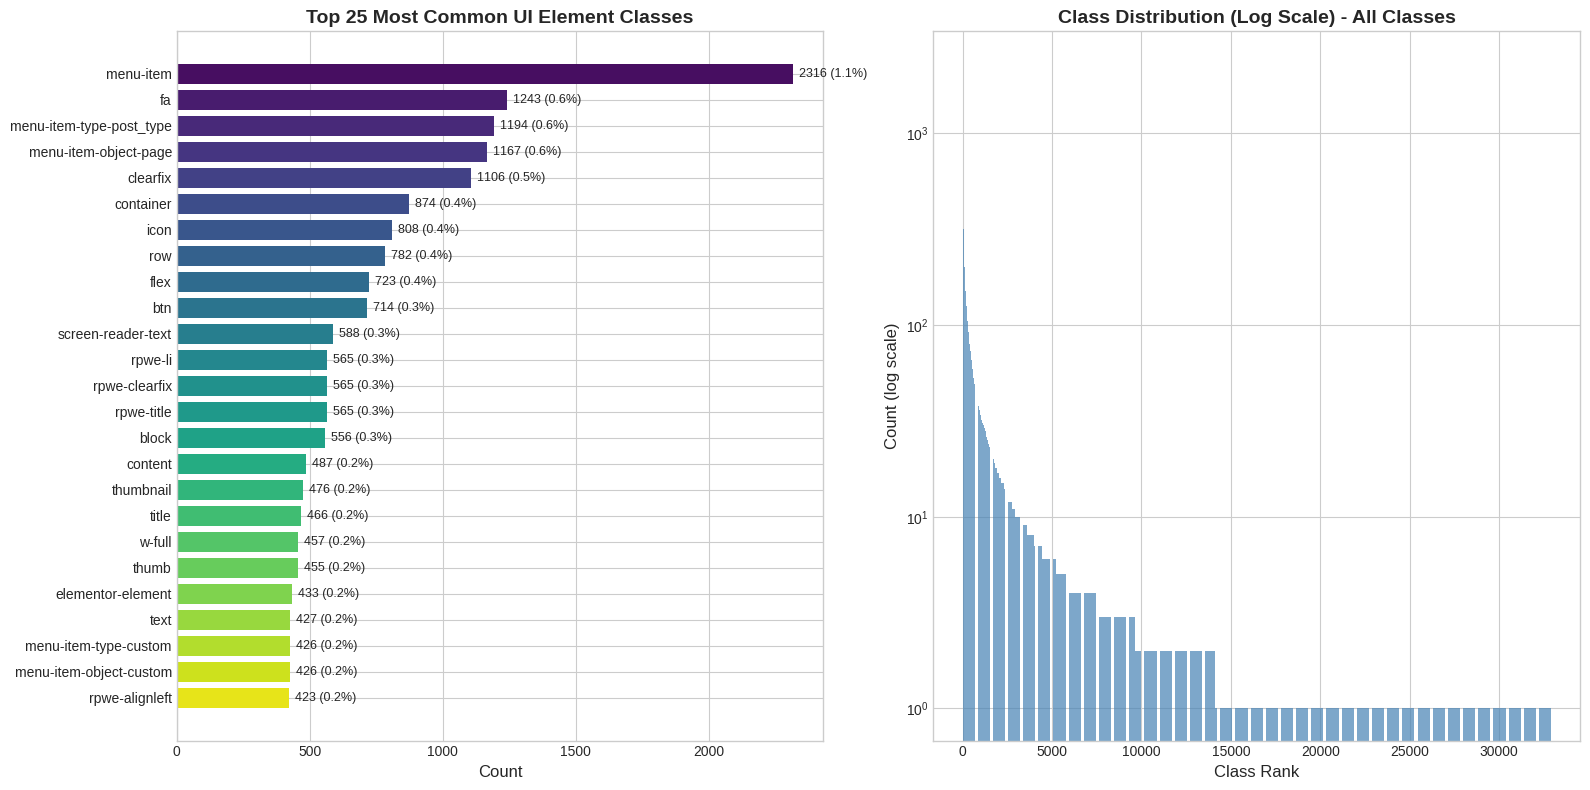

📈 Chart saved to: /mnt/c/WebUIDetection/class_distribution.png


In [9]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 25 classes bar chart
top_n = 25
ax1 = axes[0]
top_classes = class_df.head(top_n)
bars = ax1.barh(range(len(top_classes)), top_classes['Count'].values, color=sns.color_palette("viridis", top_n))
ax1.set_yticks(range(len(top_classes)))
ax1.set_yticklabels(top_classes['Class'].values)
ax1.invert_yaxis()
ax1.set_xlabel('Count', fontsize=12)
ax1.set_title(f'Top {top_n} Most Common UI Element Classes', fontsize=14, fontweight='bold')

# Add count labels
for i, (count, pct) in enumerate(zip(top_classes['Count'], top_classes['Percentage'])):
    ax1.text(count + max(top_classes['Count'])*0.01, i, f'{count} ({pct:.1f}%)', va='center', fontsize=9)

# Log-scale distribution
ax2 = axes[1]
ax2.bar(range(len(class_df)), class_df['Count'].values, color='steelblue', alpha=0.7)
ax2.set_yscale('log')
ax2.set_xlabel('Class Rank', fontsize=12)
ax2.set_ylabel('Count (log scale)', fontsize=12)
ax2.set_title('Class Distribution (Log Scale) - All Classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/mnt/c/WebUIDetection/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("📈 Chart saved to: /mnt/c/WebUIDetection/class_distribution.png")

## 6. Visualize Bounding Box Statistics

Let's analyze the bounding box dimensions across the dataset.

In [10]:
# Collect bounding box statistics
bbox_widths = []
bbox_heights = []
bbox_areas = []
bbox_x_positions = []
bbox_y_positions = []

print("🔍 Collecting bounding box statistics...")

for i, sample_id in enumerate(sample_subset[:200]):  # Use 200 samples for speed
    try:
        data = get_sample_data(sample_id)
        bboxes = data.get('bboxes', {})
        
        for bbox in bboxes.values():
            if bbox is not None and isinstance(bbox, dict):
                width = bbox.get('width', 0)
                height = bbox.get('height', 0)
                x = bbox.get('x', 0)
                y = bbox.get('y', 0)
                
                # Filter out invalid bboxes
                if width > 0 and height > 0 and width < 2000 and height < 2000:
                    bbox_widths.append(width)
                    bbox_heights.append(height)
                    bbox_areas.append(width * height)
                    bbox_x_positions.append(x)
                    bbox_y_positions.append(y)
    except Exception as e:
        pass

print(f"✅ Collected {len(bbox_widths)} valid bounding boxes")
print(f"\n📊 BOUNDING BOX STATISTICS:")
print("-" * 40)
print(f"Width  - Mean: {np.mean(bbox_widths):.1f}, Median: {np.median(bbox_widths):.1f}, Std: {np.std(bbox_widths):.1f}")
print(f"Height - Mean: {np.mean(bbox_heights):.1f}, Median: {np.median(bbox_heights):.1f}, Std: {np.std(bbox_heights):.1f}")
print(f"Area   - Mean: {np.mean(bbox_areas):.1f}, Median: {np.median(bbox_areas):.1f}")

🔍 Collecting bounding box statistics...
✅ Collected 70501 valid bounding boxes

📊 BOUNDING BOX STATISTICS:
----------------------------------------
Width  - Mean: 347.4, Median: 192.0, Std: 429.0
Height - Mean: 86.4, Median: 26.0, Std: 183.0
Area   - Mean: 67956.5, Median: 5408.0


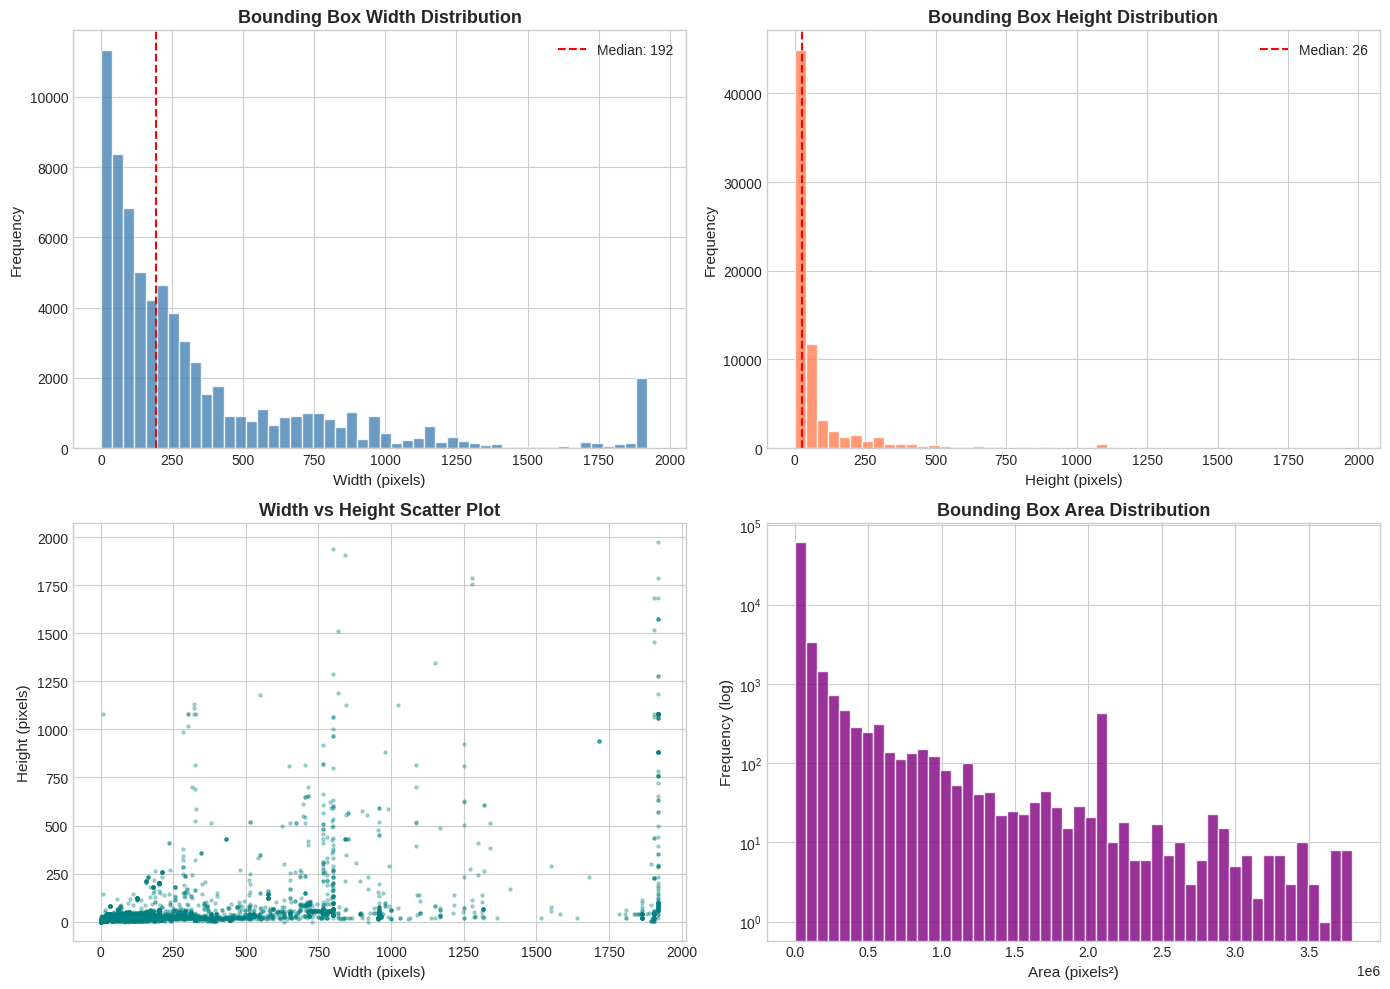

📈 Chart saved to: /mnt/c/WebUIDetection/bbox_statistics.png


In [11]:
# Visualize bounding box statistics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Width distribution
ax1 = axes[0, 0]
ax1.hist(bbox_widths, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(np.median(bbox_widths), color='red', linestyle='--', label=f'Median: {np.median(bbox_widths):.0f}')
ax1.set_xlabel('Width (pixels)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Bounding Box Width Distribution', fontsize=13, fontweight='bold')
ax1.legend()

# Height distribution
ax2 = axes[0, 1]
ax2.hist(bbox_heights, bins=50, color='coral', edgecolor='white', alpha=0.8)
ax2.axvline(np.median(bbox_heights), color='red', linestyle='--', label=f'Median: {np.median(bbox_heights):.0f}')
ax2.set_xlabel('Height (pixels)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Bounding Box Height Distribution', fontsize=13, fontweight='bold')
ax2.legend()

# Width vs Height scatter
ax3 = axes[1, 0]
ax3.scatter(bbox_widths[:5000], bbox_heights[:5000], alpha=0.3, s=5, c='teal')
ax3.set_xlabel('Width (pixels)', fontsize=11)
ax3.set_ylabel('Height (pixels)', fontsize=11)
ax3.set_title('Width vs Height Scatter Plot', fontsize=13, fontweight='bold')

# Area distribution (log scale)
ax4 = axes[1, 1]
ax4.hist(bbox_areas, bins=50, color='purple', edgecolor='white', alpha=0.8)
ax4.set_yscale('log')
ax4.set_xlabel('Area (pixels²)', fontsize=11)
ax4.set_ylabel('Frequency (log)', fontsize=11)
ax4.set_title('Bounding Box Area Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/mnt/c/WebUIDetection/bbox_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

print("📈 Chart saved to: /mnt/c/WebUIDetection/bbox_statistics.png")

## 7. Sample Image Visualization with Annotations

Let's display some sample images with their bounding box annotations.

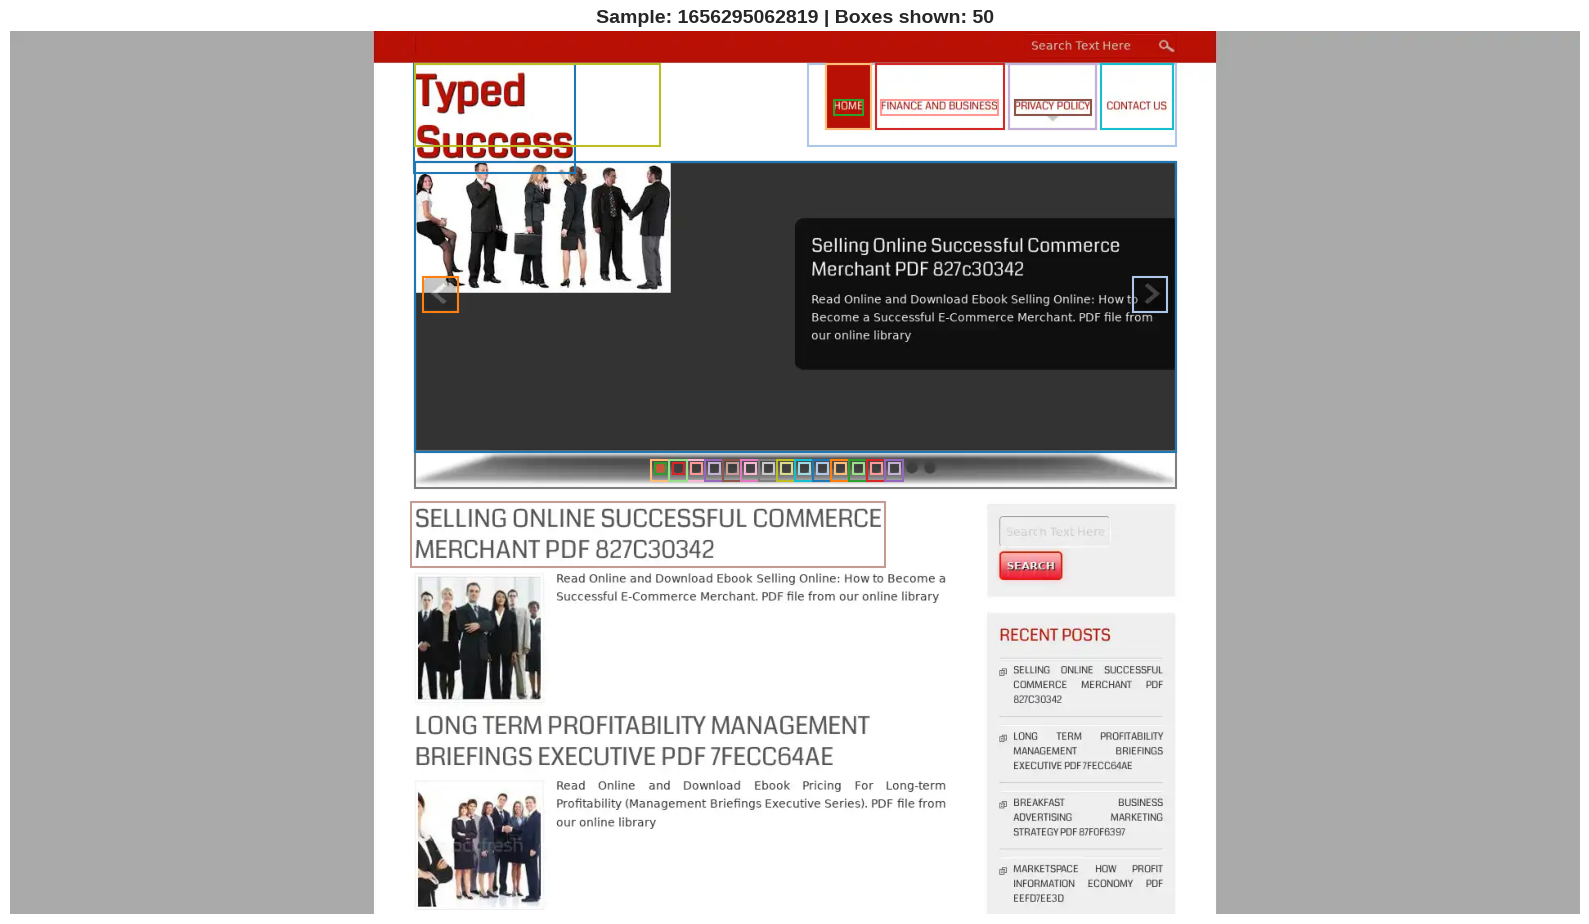

--------------------------------------------------------------------------------


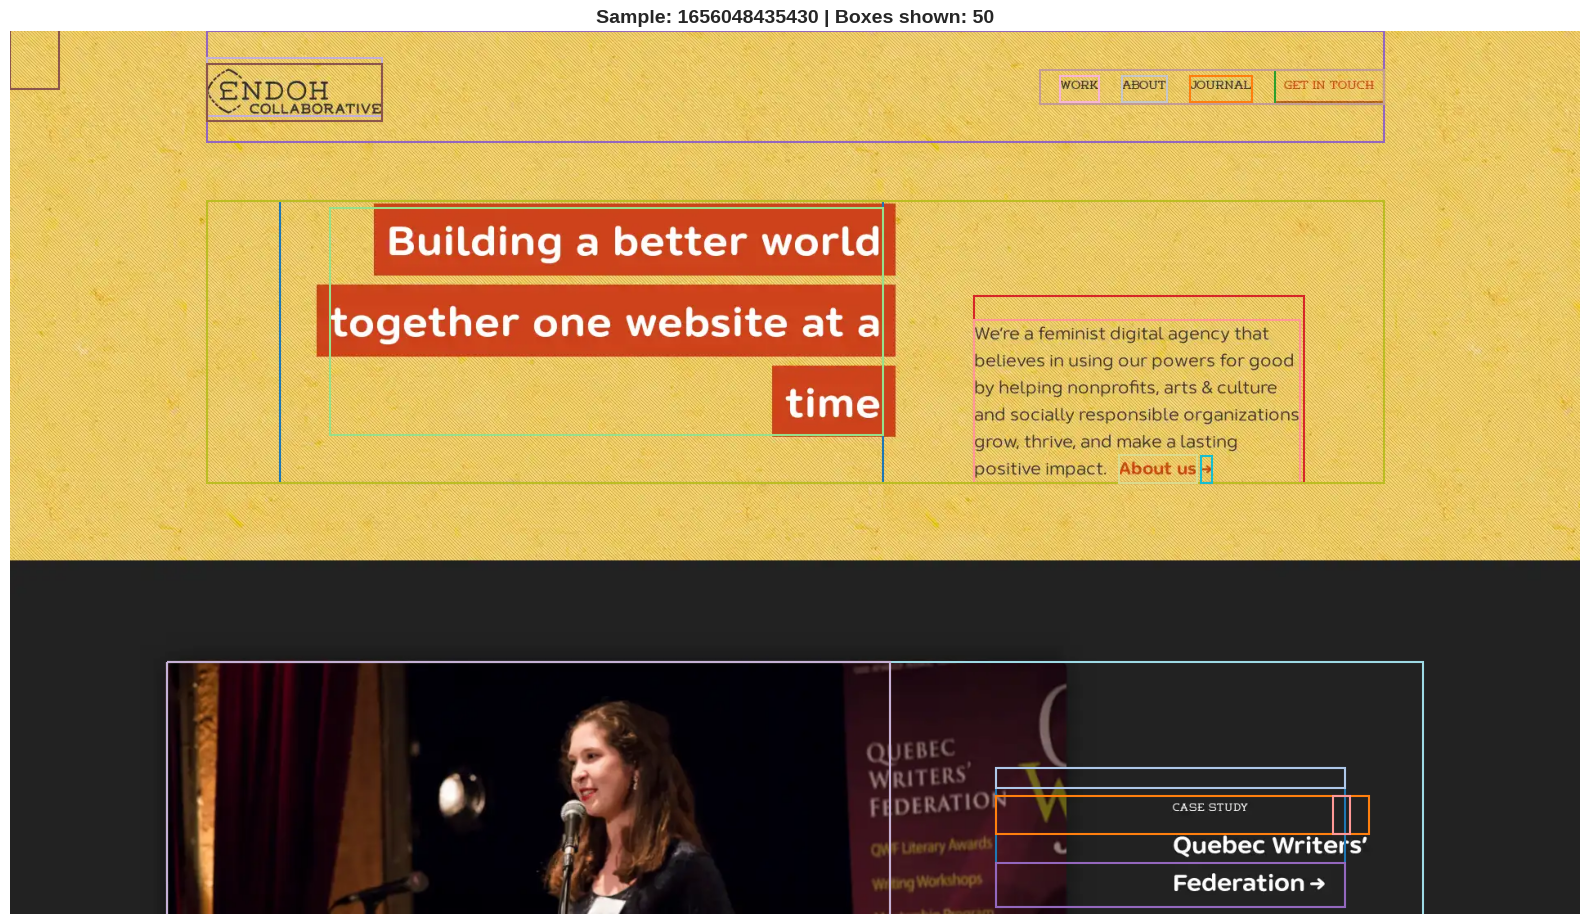

--------------------------------------------------------------------------------


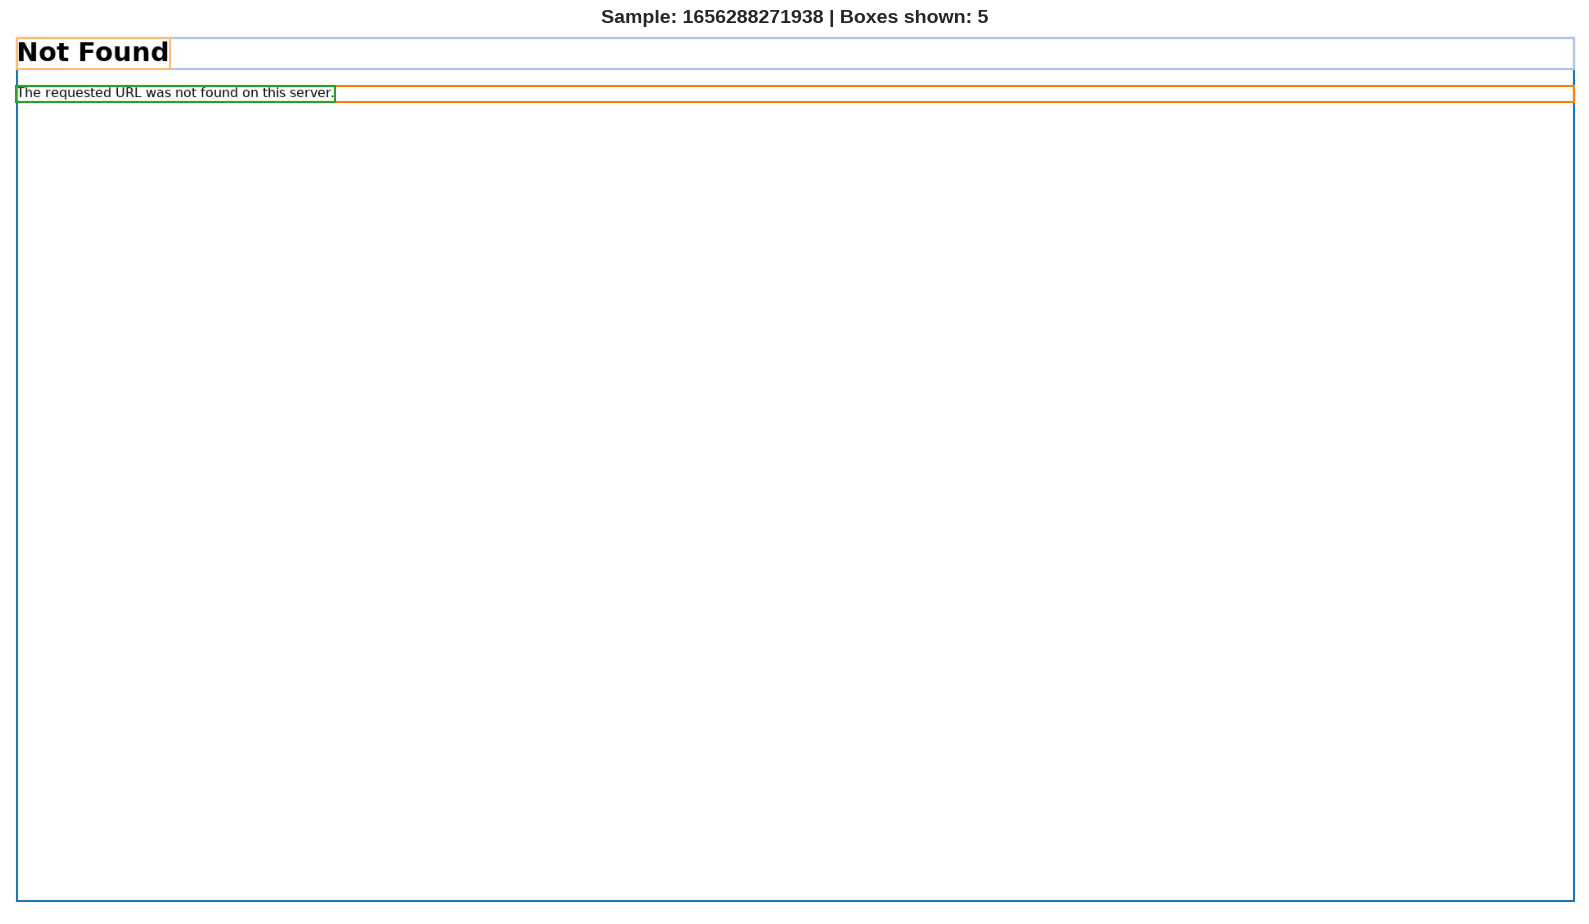

--------------------------------------------------------------------------------


In [12]:
def visualize_sample_with_bboxes(sample_id, resolution="1920-1080", max_boxes=50):
    """Visualize a sample image with bounding boxes."""
    data = get_sample_data(sample_id, resolution)
    
    if 'screenshot_path' not in data:
        print(f"No screenshot found for sample {sample_id}")
        return None
    
    # Load image
    img = Image.open(data['screenshot_path'])
    img_array = np.array(img)
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(16, 10))
    ax.imshow(img_array)
    
    # Draw bounding boxes
    bboxes = data.get('bboxes', {})
    colors = plt.cm.tab20(np.linspace(0, 1, 20))
    
    box_count = 0
    for key, bbox in bboxes.items():
        if bbox is not None and isinstance(bbox, dict) and box_count < max_boxes:
            x = bbox.get('x', 0)
            y = bbox.get('y', 0)
            w = bbox.get('width', 0)
            h = bbox.get('height', 0)
            
            # Filter small or invalid boxes
            if w > 5 and h > 5 and w < 1920 and h < 1080:
                color = colors[box_count % 20]
                rect = plt.Rectangle((x, y), w, h, 
                                     fill=False, edgecolor=color, linewidth=1.5)
                ax.add_patch(rect)
                box_count += 1
    
    ax.set_title(f'Sample: {sample_id} | Boxes shown: {box_count}', fontsize=14, fontweight='bold')
    ax.axis('off')
    
    return fig

# Visualize 3 random samples
random_samples = random.sample(sample_folders, 3)

for sample_id in random_samples:
    fig = visualize_sample_with_bboxes(sample_id)
    if fig:
        plt.tight_layout()
        plt.show()
    print("-" * 80)

## 8. Analyze Image Dimensions and Aspect Ratios

In [13]:
# Check available resolutions and image dimensions
resolution_counts = {'1920x1080': 0, '1366x768': 0}
image_dimensions = []

print("🔍 Analyzing image dimensions...")

for i, sample_id in enumerate(sample_subset[:100]):
    sample_path = os.path.join(DATASET_PATH, sample_id)
    
    # Check for different resolutions
    if os.path.exists(os.path.join(sample_path, "default_1920-1080-screenshot.webp")):
        resolution_counts['1920x1080'] += 1
        img = Image.open(os.path.join(sample_path, "default_1920-1080-screenshot.webp"))
        image_dimensions.append(img.size)
    
    if os.path.exists(os.path.join(sample_path, "default_1366-768-screenshot.webp")):
        resolution_counts['1366x768'] += 1

print("\n📊 AVAILABLE RESOLUTIONS:")
print("-" * 40)
for res, count in resolution_counts.items():
    print(f"   {res}: {count} samples ({count/100*100:.0f}%)")

# Analyze actual image dimensions
if image_dimensions:
    widths, heights = zip(*image_dimensions)
    print(f"\n📐 ACTUAL IMAGE DIMENSIONS (from 1920x1080 screenshots):")
    print(f"   Width  - Min: {min(widths)}, Max: {max(widths)}, Unique: {len(set(widths))}")
    print(f"   Height - Min: {min(heights)}, Max: {max(heights)}, Unique: {len(set(heights))}")

🔍 Analyzing image dimensions...

📊 AVAILABLE RESOLUTIONS:
----------------------------------------
   1920x1080: 100 samples (100%)
   1366x768: 100 samples (100%)

📐 ACTUAL IMAGE DIMENSIONS (from 1920x1080 screenshots):
   Width  - Min: 1920, Max: 1920, Unique: 1
   Height - Min: 1080, Max: 1080, Unique: 1


## 9. Class Imbalance Analysis

In [14]:
# Analyze class imbalance
print("📊 CLASS IMBALANCE ANALYSIS:")
print("=" * 60)

# Calculate imbalance metrics
max_count = class_df['Count'].max()
min_count = class_df['Count'].min()
imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

print(f"Most common class: {class_df.iloc[0]['Class']} ({max_count} occurrences)")
print(f"Least common class: {class_df.iloc[-1]['Class']} ({min_count} occurrences)")
print(f"Imbalance Ratio: {imbalance_ratio:.2f}x")

# Categorize classes by frequency
class_df['Category'] = pd.cut(class_df['Count'], 
                               bins=[0, 10, 100, 1000, float('inf')],
                               labels=['Rare (<10)', 'Uncommon (10-100)', 'Common (100-1000)', 'Very Common (>1000)'])

category_counts = class_df['Category'].value_counts().sort_index()
print(f"\n📋 CLASS FREQUENCY CATEGORIES:")
for cat, count in category_counts.items():
    print(f"   {cat}: {count} classes")

📊 CLASS IMBALANCE ANALYSIS:
Most common class: menu-item (2316 occurrences)
Least common class: icon-magnifying-glass (1 occurrences)
Imbalance Ratio: 2316.00x

📋 CLASS FREQUENCY CATEGORIES:
   Rare (<10): 29949 classes
   Uncommon (10-100): 2648 classes
   Common (100-1000): 284 classes
   Very Common (>1000): 5 classes


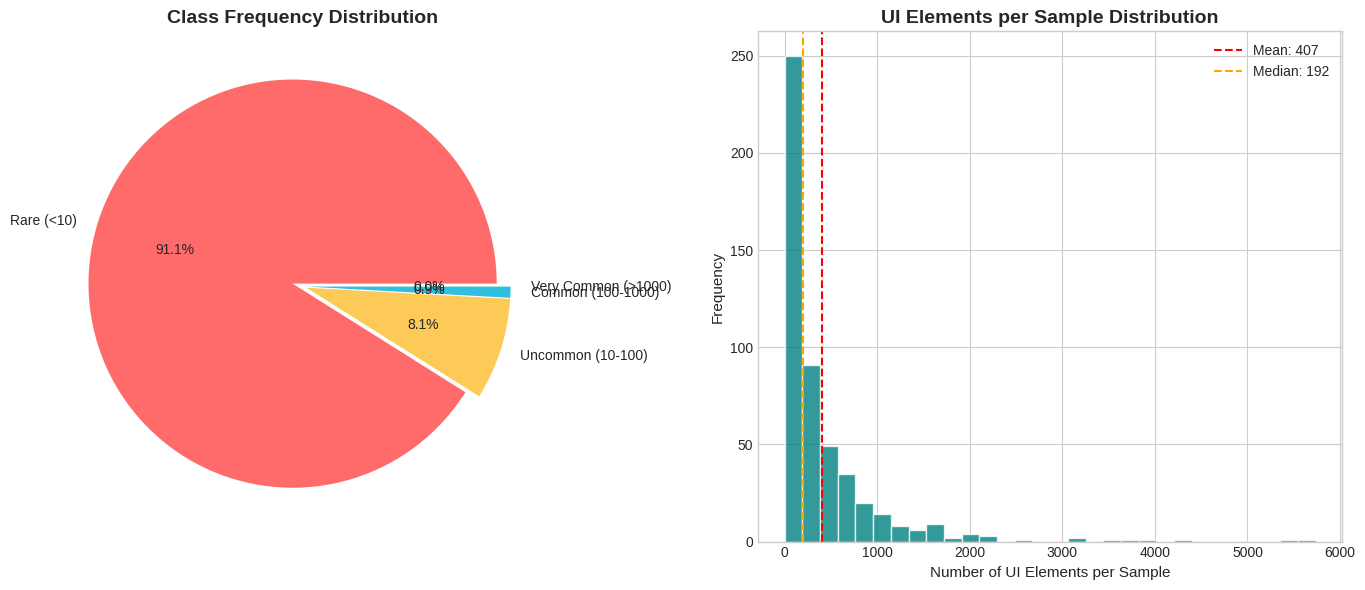

📈 Chart saved to: /mnt/c/WebUIDetection/class_imbalance.png


In [15]:
# Visualize class imbalance with pie chart and category distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart of category distribution
ax1 = axes[0]
colors = ['#ff6b6b', '#feca57', "#30bfdf", '#1dd1a1']
wedges, texts, autotexts = ax1.pie(category_counts.values, 
                                    labels=category_counts.index, 
                                    autopct='%1.1f%%',
                                    colors=colors,
                                    explode=(0.05, 0.02, 0.02, 0.02))
ax1.set_title('Class Frequency Distribution', fontsize=14, fontweight='bold')

# Elements per sample histogram
ax2 = axes[1]
ax2.hist(elements_per_sample, bins=30, color='teal', edgecolor='white', alpha=0.8)
ax2.axvline(np.mean(elements_per_sample), color='red', linestyle='--', 
            label=f'Mean: {np.mean(elements_per_sample):.0f}')
ax2.axvline(np.median(elements_per_sample), color='orange', linestyle='--',
            label=f'Median: {np.median(elements_per_sample):.0f}')
ax2.set_xlabel('Number of UI Elements per Sample', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('UI Elements per Sample Distribution', fontsize=14, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig('/mnt/c/WebUIDetection/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print("📈 Chart saved to: /mnt/c/WebUIDetection/class_imbalance.png")

## 10. Training Method Recommendations for YOLO v11

Based on the dataset analysis, here are the recommended configurations for training YOLO v11 on this WebUI dataset.

In [16]:
# Training Recommendations Summary
print("=" * 70)
print("🎯 YOLO V11 TRAINING RECOMMENDATIONS FOR WEBUI-7K")
print("=" * 70)

print("\n📐 IMAGE SIZE RECOMMENDATIONS:")
print("-" * 50)
print("   • Original resolution: 1920x1080 (16:9 aspect ratio)")
print("   • Recommended YOLO input: 640x640 (standard) or 960x544 (preserve aspect)")
print("   • For RTX 3050 4GB VRAM: Use 640x640 to fit in memory")

print("\n⚙️ BATCH SIZE RECOMMENDATIONS:")
print("-" * 50)
print("   • RTX 3050 4GB VRAM limit")
print("   • YOLOv11n (nano): batch_size = 8-16")
print("   • YOLOv11s (small): batch_size = 4-8")
print("   • YOLOv11m (medium): batch_size = 2-4")
print("   • Recommended: Start with YOLOv11n, batch_size=8")

print("\n🔧 CLASS HANDLING STRATEGY:")
print("-" * 50)
print(f"   • Total unique classes: {len(class_df)}")
print("   • Many CSS class names - consider grouping into semantic categories:")
print("     - Buttons, Links, Text inputs, Dropdowns, Images, Icons, etc.")
print("   • Use class weights or focal loss to handle imbalance")

print("\n📈 AUGMENTATION RECOMMENDATIONS:")
print("-" * 50)
print("   • Horizontal flip: DISABLED (web layouts are asymmetric)")
print("   • Vertical flip: DISABLED")
print("   • Scale: 0.5 to 1.5")
print("   • Mosaic: Useful for small objects")
print("   • Color jitter: Light augmentation (web has consistent colors)")

print("\n💡 TRAINING TIPS:")
print("-" * 50)
print("   • Use mixed precision (FP16) to reduce memory")
print("   • Enable gradient checkpointing if needed")
print("   • Start with pretrained COCO weights")
print("   • Learning rate: 0.01 with cosine scheduler")
print("   • Train for 100-300 epochs with early stopping")

🎯 YOLO V11 TRAINING RECOMMENDATIONS FOR WEBUI-7K

📐 IMAGE SIZE RECOMMENDATIONS:
--------------------------------------------------
   • Original resolution: 1920x1080 (16:9 aspect ratio)
   • Recommended YOLO input: 640x640 (standard) or 960x544 (preserve aspect)
   • For RTX 3050 4GB VRAM: Use 640x640 to fit in memory

⚙️ BATCH SIZE RECOMMENDATIONS:
--------------------------------------------------
   • RTX 3050 4GB VRAM limit
   • YOLOv11n (nano): batch_size = 8-16
   • YOLOv11s (small): batch_size = 4-8
   • YOLOv11m (medium): batch_size = 2-4
   • Recommended: Start with YOLOv11n, batch_size=8

🔧 CLASS HANDLING STRATEGY:
--------------------------------------------------
   • Total unique classes: 32886
   • Many CSS class names - consider grouping into semantic categories:
     - Buttons, Links, Text inputs, Dropdowns, Images, Icons, etc.
   • Use class weights or focal loss to handle imbalance

📈 AUGMENTATION RECOMMENDATIONS:
--------------------------------------------------
  

### YOLO Format Conversion

To train YOLO v11, we need to convert the WebUI annotations to YOLO format:
- YOLO format: `class_id center_x center_y width height` (normalized 0-1)
- Each image needs a corresponding `.txt` file with annotations

In [17]:
def convert_to_yolo_format(bbox, img_width, img_height):
    """
    Convert WebUI bbox format to YOLO format.
    
    WebUI: {'x': left, 'y': top, 'width': w, 'height': h} in pixels
    YOLO:  center_x, center_y, width, height (normalized 0-1)
    """
    x = bbox.get('x', 0)
    y = bbox.get('y', 0)
    w = bbox.get('width', 0)
    h = bbox.get('height', 0)
    
    # Calculate center
    center_x = (x + w / 2) / img_width
    center_y = (y + h / 2) / img_height
    norm_w = w / img_width
    norm_h = h / img_height
    
    # Clip to valid range
    center_x = max(0, min(1, center_x))
    center_y = max(0, min(1, center_y))
    norm_w = max(0, min(1, norm_w))
    norm_h = max(0, min(1, norm_h))
    
    return center_x, center_y, norm_w, norm_h

# Example conversion
example_bbox = {'x': 100, 'y': 200, 'width': 150, 'height': 50}
yolo_coords = convert_to_yolo_format(example_bbox, 1920, 1080)
print("🔄 YOLO FORMAT CONVERSION EXAMPLE:")
print(f"   WebUI format: {example_bbox}")
print(f"   YOLO format:  class_id {yolo_coords[0]:.6f} {yolo_coords[1]:.6f} {yolo_coords[2]:.6f} {yolo_coords[3]:.6f}")

🔄 YOLO FORMAT CONVERSION EXAMPLE:
   WebUI format: {'x': 100, 'y': 200, 'width': 150, 'height': 50}
   YOLO format:  class_id 0.091146 0.208333 0.078125 0.046296


## Summary and Next Steps

### Key Findings:
1. **Dataset Size**: ~7,000 web page screenshots with UI element annotations
2. **Resolution**: Two resolutions available (1920x1080 and 1366x768)
3. **Annotations**: Detailed bounding boxes with CSS class names
4. **Class Variety**: Many unique class names (CSS-based), need semantic grouping

### Recommended Next Steps:
1. **Define semantic classes**: Group CSS classes into ~20-30 meaningful UI categories
2. **Convert to YOLO format**: Create dataset in YOLO-compatible structure
3. **Train baseline model**: Start with YOLOv11n for quick iteration
4. **Evaluate and iterate**: Fine-tune hyperparameters based on validation results

### Hardware Constraints (RTX 3050 4GB):
- Use YOLOv11n or YOLOv11s models
- Batch size: 4-8 depending on image size
- Enable mixed precision training (FP16)
- Use gradient accumulation if needed

## 11. YOLO v11 Training Implementation

Now we'll implement the complete training pipeline for YOLO v11 using Ultralytics and PyTorch.

### Steps:
1. Define semantic class mappings (group CSS classes into meaningful UI categories)
2. Convert dataset to YOLO format (images + labels)
3. Create dataset YAML configuration
4. Configure and run training

In [18]:
# Define semantic UI class mappings
# Map common CSS class patterns to semantic UI categories

SEMANTIC_CLASSES = {
    0: 'button',
    1: 'link',
    2: 'text_input',
    3: 'image',
    4: 'icon',
    5: 'dropdown',
    6: 'checkbox',
    7: 'radio',
    8: 'container',
    9: 'navigation',
    10: 'header',
    11: 'footer',
    12: 'card',
    13: 'modal',
    14: 'menu',
    15: 'list_item',
    16: 'form',
    17: 'video',
    18: 'slider',
    19: 'other'
}

# Reverse mapping for lookup
CLASS_TO_ID = {v: k for k, v in SEMANTIC_CLASSES.items()}

# Define CSS class pattern matching rules
CLASS_PATTERNS = {
    'button': ['btn', 'button', 'submit', 'cta', 'action'],
    'link': ['link', 'anchor', 'href', 'nav-link', 'a-'],
    'text_input': ['input', 'textfield', 'text-box', 'search', 'form-control', 'textarea'],
    'image': ['img', 'image', 'photo', 'picture', 'thumbnail', 'avatar'],
    'icon': ['icon', 'fa-', 'material-icons', 'svg', 'glyph'],
    'dropdown': ['dropdown', 'select', 'combobox', 'menu-toggle'],
    'checkbox': ['checkbox', 'check-box', 'tick'],
    'radio': ['radio', 'radio-button'],
    'container': ['container', 'wrapper', 'section', 'box', 'panel', 'row', 'col'],
    'navigation': ['nav', 'navbar', 'sidebar', 'breadcrumb', 'pagination'],
    'header': ['header', 'heading', 'title', 'h1', 'h2', 'h3', 'banner'],
    'footer': ['footer', 'copyright'],
    'card': ['card', 'tile', 'item-card'],
    'modal': ['modal', 'dialog', 'popup', 'overlay', 'lightbox'],
    'menu': ['menu', 'menuitem', 'menu-item'],
    'list_item': ['list-item', 'li', 'item', 'entry'],
    'form': ['form', 'form-group', 'fieldset'],
    'video': ['video', 'player', 'embed'],
    'slider': ['slider', 'carousel', 'range', 'swiper'],
}

def classify_element(css_classes):
    """
    Classify an element based on its CSS class names.
    Returns the semantic class ID.
    """
    if not css_classes:
        return CLASS_TO_ID['other']
    
    # Convert to lowercase string for matching
    if isinstance(css_classes, dict):
        class_str = ' '.join(str(v).lower() for v in css_classes.values())
    elif isinstance(css_classes, (list, tuple)):
        class_str = ' '.join(str(c).lower() for c in css_classes)
    else:
        class_str = str(css_classes).lower()
    
    # Check each pattern category
    for semantic_class, patterns in CLASS_PATTERNS.items():
        for pattern in patterns:
            if pattern in class_str:
                return CLASS_TO_ID[semantic_class]
    
    return CLASS_TO_ID['other']

# Test the classification
test_classes = [
    {'class': 'btn btn-primary'},
    {'class': 'nav-link active'},
    {'class': 'form-control input-text'},
    {'class': 'fa fa-search icon'},
    {'class': 'unknown-class'}
]

print("🏷️ SEMANTIC CLASS MAPPING TEST:")
print("-" * 50)
for test in test_classes:
    class_id = classify_element(test)
    class_name = SEMANTIC_CLASSES[class_id]
    print(f"   {test} → {class_name} (ID: {class_id})")

print(f"\n📊 Total semantic classes defined: {len(SEMANTIC_CLASSES)}")

🏷️ SEMANTIC CLASS MAPPING TEST:
--------------------------------------------------
   {'class': 'btn btn-primary'} → button (ID: 0)
   {'class': 'nav-link active'} → link (ID: 1)
   {'class': 'form-control input-text'} → text_input (ID: 2)
   {'class': 'fa fa-search icon'} → link (ID: 1)
   {'class': 'unknown-class'} → other (ID: 19)

📊 Total semantic classes defined: 20


### 11.1 Convert Dataset to YOLO Format

We'll create a YOLO-compatible dataset structure:
```
datasets/
├── webui/
│   ├── images/
│   │   ├── train/
│   │   └── val/
│   ├── labels/
│   │   ├── train/
│   │   └── val/
│   └── data.yaml
```

In [19]:
import shutil
from tqdm import tqdm

# Dataset output paths
YOLO_DATASET_PATH = "/mnt/c/WebUIDetection/datasets/webui"
TRAIN_IMAGES_PATH = os.path.join(YOLO_DATASET_PATH, "images", "train")
VAL_IMAGES_PATH = os.path.join(YOLO_DATASET_PATH, "images", "val")
TRAIN_LABELS_PATH = os.path.join(YOLO_DATASET_PATH, "labels", "train")
VAL_LABELS_PATH = os.path.join(YOLO_DATASET_PATH, "labels", "val")

# Create directory structure
for path in [TRAIN_IMAGES_PATH, VAL_IMAGES_PATH, TRAIN_LABELS_PATH, VAL_LABELS_PATH]:
    os.makedirs(path, exist_ok=True)

print("📁 Created YOLO dataset directory structure:")
print(f"   {YOLO_DATASET_PATH}/")
print(f"   ├── images/train/")
print(f"   ├── images/val/")
print(f"   ├── labels/train/")
print(f"   └── labels/val/")

📁 Created YOLO dataset directory structure:
   /mnt/c/WebUIDetection/datasets/webui/
   ├── images/train/
   ├── images/val/
   ├── labels/train/
   └── labels/val/


In [20]:
def convert_sample_to_yolo(sample_id, output_images_path, output_labels_path, resolution="1920-1080"):
    """
    Convert a single sample to YOLO format.
    
    Returns:
        tuple: (success: bool, num_annotations: int)
    """
    sample_path = os.path.join(DATASET_PATH, sample_id)
    screenshot_path = os.path.join(sample_path, f"default_{resolution}-screenshot.webp")
    
    # Check if screenshot exists
    if not os.path.exists(screenshot_path):
        return False, 0
    
    # Load image to get dimensions
    try:
        img = Image.open(screenshot_path)
        img_width, img_height = img.size
    except Exception as e:
        return False, 0
    
    # Load bboxes and classes
    try:
        data = get_sample_data(sample_id, resolution)
        bboxes = data.get('bboxes', {})
        classes = data.get('classes', {})
    except Exception as e:
        return False, 0
    
    # Convert annotations to YOLO format
    yolo_annotations = []
    
    for element_id, bbox in bboxes.items():
        if bbox is None or not isinstance(bbox, dict):
            continue
        
        # Get bbox coordinates
        x = bbox.get('x', 0)
        y = bbox.get('y', 0)
        w = bbox.get('width', 0)
        h = bbox.get('height', 0)
        
        # Skip invalid or too small/large bboxes
        if w <= 2 or h <= 2 or w >= img_width or h >= img_height:
            continue
        
        # Skip bboxes that are mostly outside the image
        if x + w <= 0 or y + h <= 0 or x >= img_width or y >= img_height:
            continue
        
        # Clip bbox to image boundaries
        x = max(0, x)
        y = max(0, y)
        w = min(w, img_width - x)
        h = min(h, img_height - y)
        
        # Get semantic class
        element_classes = classes.get(element_id, {})
        class_id = classify_element(element_classes)
        
        # Convert to YOLO format (normalized center coordinates)
        center_x = (x + w / 2) / img_width
        center_y = (y + h / 2) / img_height
        norm_w = w / img_width
        norm_h = h / img_height
        
        # Validate normalized values
        if 0 <= center_x <= 1 and 0 <= center_y <= 1 and norm_w > 0 and norm_h > 0:
            yolo_annotations.append(f"{class_id} {center_x:.6f} {center_y:.6f} {norm_w:.6f} {norm_h:.6f}")
    
    # Skip samples with no valid annotations
    if len(yolo_annotations) == 0:
        return False, 0
    
    # Copy image (convert webp to jpg for better compatibility)
    output_image_path = os.path.join(output_images_path, f"{sample_id}.jpg")
    try:
        img_rgb = img.convert('RGB')
        img_rgb.save(output_image_path, 'JPEG', quality=95)
    except Exception as e:
        return False, 0
    
    # Write YOLO label file
    output_label_path = os.path.join(output_labels_path, f"{sample_id}.txt")
    with open(output_label_path, 'w') as f:
        f.write('\n'.join(yolo_annotations))
    
    return True, len(yolo_annotations)

# Test conversion on one sample
test_sample = sample_folders[0]
success, num_annots = convert_sample_to_yolo(test_sample, TRAIN_IMAGES_PATH, TRAIN_LABELS_PATH)
print(f"🧪 Test conversion: {test_sample}")
print(f"   Success: {success}")
print(f"   Annotations: {num_annots}")

# Clean up test file
if success:
    os.remove(os.path.join(TRAIN_IMAGES_PATH, f"{test_sample}.jpg"))
    os.remove(os.path.join(TRAIN_LABELS_PATH, f"{test_sample}.txt"))
    print("   ✅ Test files cleaned up")

🧪 Test conversion: 1655885421832
   Success: True
   Annotations: 872
   ✅ Test files cleaned up


In [21]:
# Convert full dataset with train/val split
from sklearn.model_selection import train_test_split

# Split dataset into train/val (85%/15%)
TRAIN_SPLIT = 0.85
VAL_SPLIT = 0.15

train_samples, val_samples = train_test_split(
    sample_folders, 
    test_size=VAL_SPLIT, 
    random_state=42
)

print(f"📊 Dataset Split:")
print(f"   Training samples: {len(train_samples)}")
print(f"   Validation samples: {len(val_samples)}")
print(f"   Total: {len(sample_folders)}")

📊 Dataset Split:
   Training samples: 5881
   Validation samples: 1038
   Total: 6919


In [22]:
# Convert training samples
print("🔄 Converting training samples to YOLO format...")
train_success = 0
train_annotations = 0

for sample_id in tqdm(train_samples, desc="Training"):
    success, num_annots = convert_sample_to_yolo(sample_id, TRAIN_IMAGES_PATH, TRAIN_LABELS_PATH)
    if success:
        train_success += 1
        train_annotations += num_annots

print(f"\n✅ Training set conversion complete:")
print(f"   Successful: {train_success}/{len(train_samples)}")
print(f"   Total annotations: {train_annotations}")

# Convert validation samples
print("\n🔄 Converting validation samples to YOLO format...")
val_success = 0
val_annotations = 0

for sample_id in tqdm(val_samples, desc="Validation"):
    success, num_annots = convert_sample_to_yolo(sample_id, VAL_IMAGES_PATH, VAL_LABELS_PATH)
    if success:
        val_success += 1
        val_annotations += num_annots

print(f"\n✅ Validation set conversion complete:")
print(f"   Successful: {val_success}/{len(val_samples)}")
print(f"   Total annotations: {val_annotations}")

print(f"\n📊 FINAL DATASET STATISTICS:")
print(f"   Training images: {train_success}")
print(f"   Training annotations: {train_annotations}")
print(f"   Validation images: {val_success}")
print(f"   Validation annotations: {val_annotations}")

🔄 Converting training samples to YOLO format...


Training: 100%|██████████| 5881/5881 [14:43<00:00,  6.66it/s]  



✅ Training set conversion complete:
   Successful: 5818/5881
   Total annotations: 734201

🔄 Converting validation samples to YOLO format...


Validation: 100%|██████████| 1038/1038 [01:40<00:00, 10.36it/s]


✅ Validation set conversion complete:
   Successful: 1024/1038
   Total annotations: 133122

📊 FINAL DATASET STATISTICS:
   Training images: 5818
   Training annotations: 734201
   Validation images: 1024
   Validation annotations: 133122


### 11.2 Create Dataset Configuration (data.yaml)

In [23]:
import yaml

# Create data.yaml configuration for YOLO training
data_config = {
    'path': YOLO_DATASET_PATH,
    'train': 'images/train',
    'val': 'images/val',
    'nc': len(SEMANTIC_CLASSES),
    'names': list(SEMANTIC_CLASSES.values())
}

# Write data.yaml
data_yaml_path = os.path.join(YOLO_DATASET_PATH, 'data.yaml')
with open(data_yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False, sort_keys=False)

print("📄 Created data.yaml configuration:")
print("-" * 50)
with open(data_yaml_path, 'r') as f:
    print(f.read())

📄 Created data.yaml configuration:
--------------------------------------------------
path: /mnt/c/WebUIDetection/datasets/webui
train: images/train
val: images/val
nc: 20
names:
- button
- link
- text_input
- image
- icon
- dropdown
- checkbox
- radio
- container
- navigation
- header
- footer
- card
- modal
- menu
- list_item
- form
- video
- slider
- other



### 11.3 Verify Dataset Integrity

Let's verify that the converted dataset is correct by checking a few samples.

🔍 Verifying YOLO dataset conversion:
--------------------------------------------------
✅ 1655885421832.jpg: 872 annotations


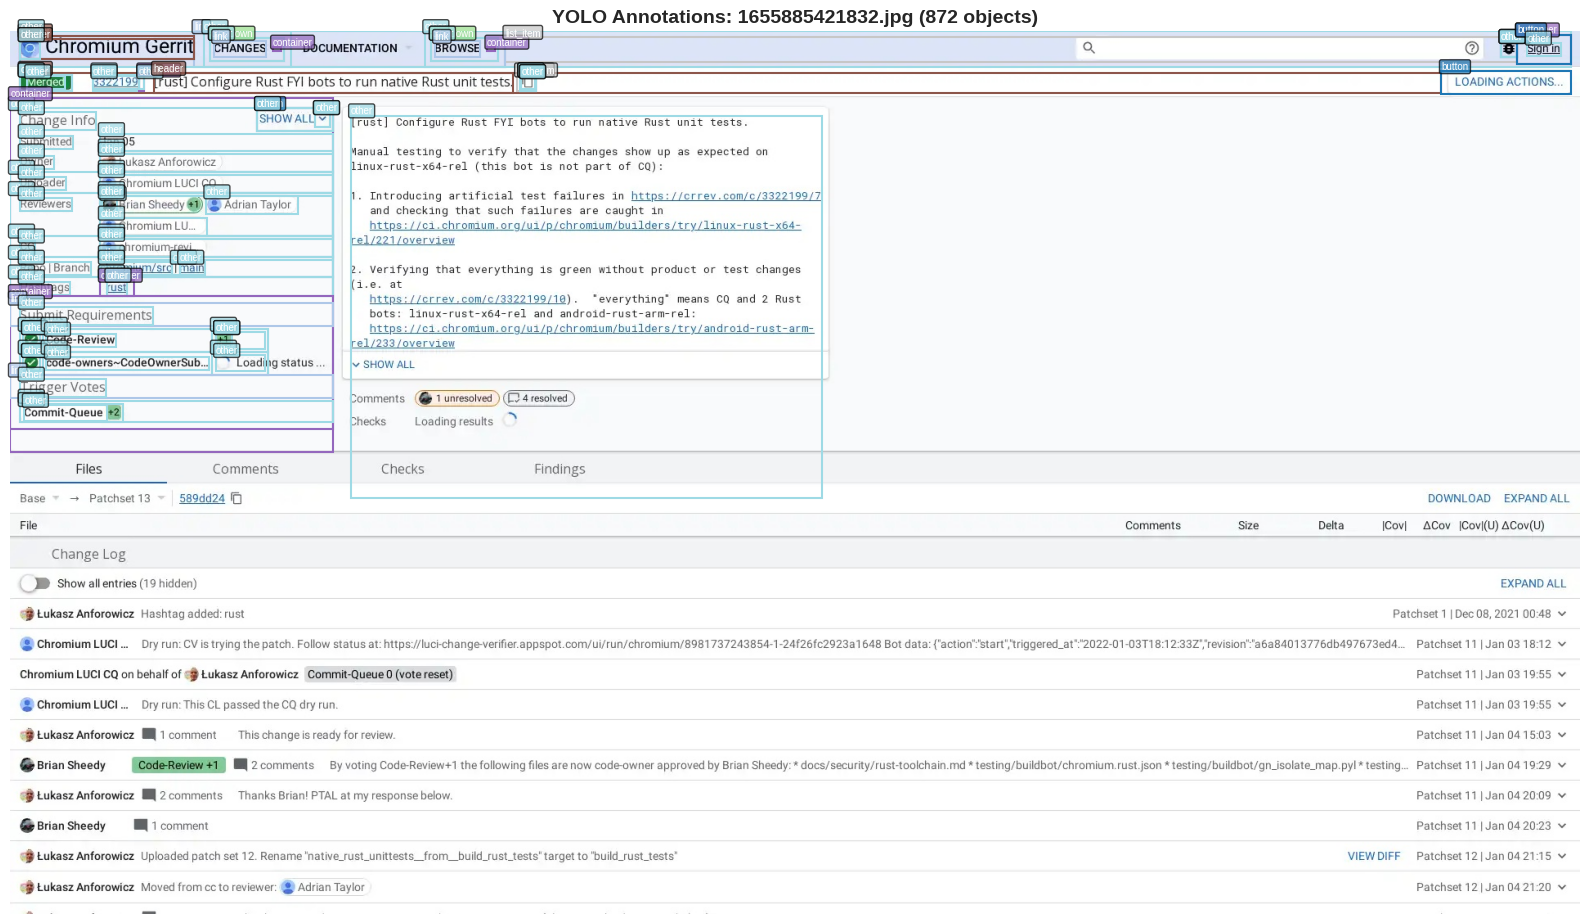

✅ 1655885631145.jpg: 187 annotations


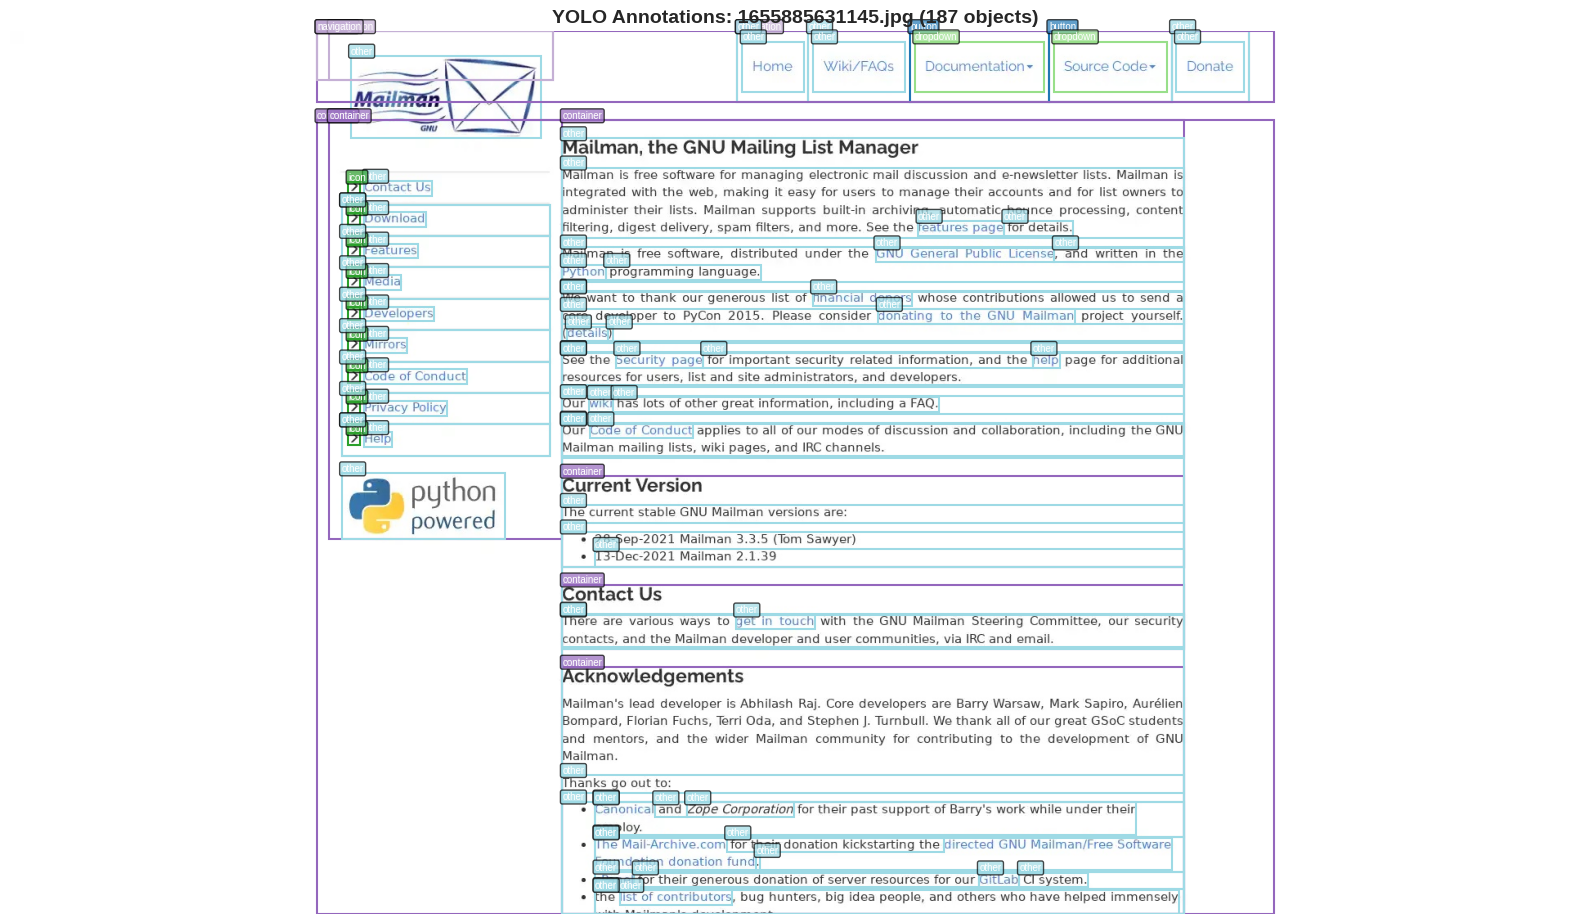

✅ 1655885744591.jpg: 106 annotations


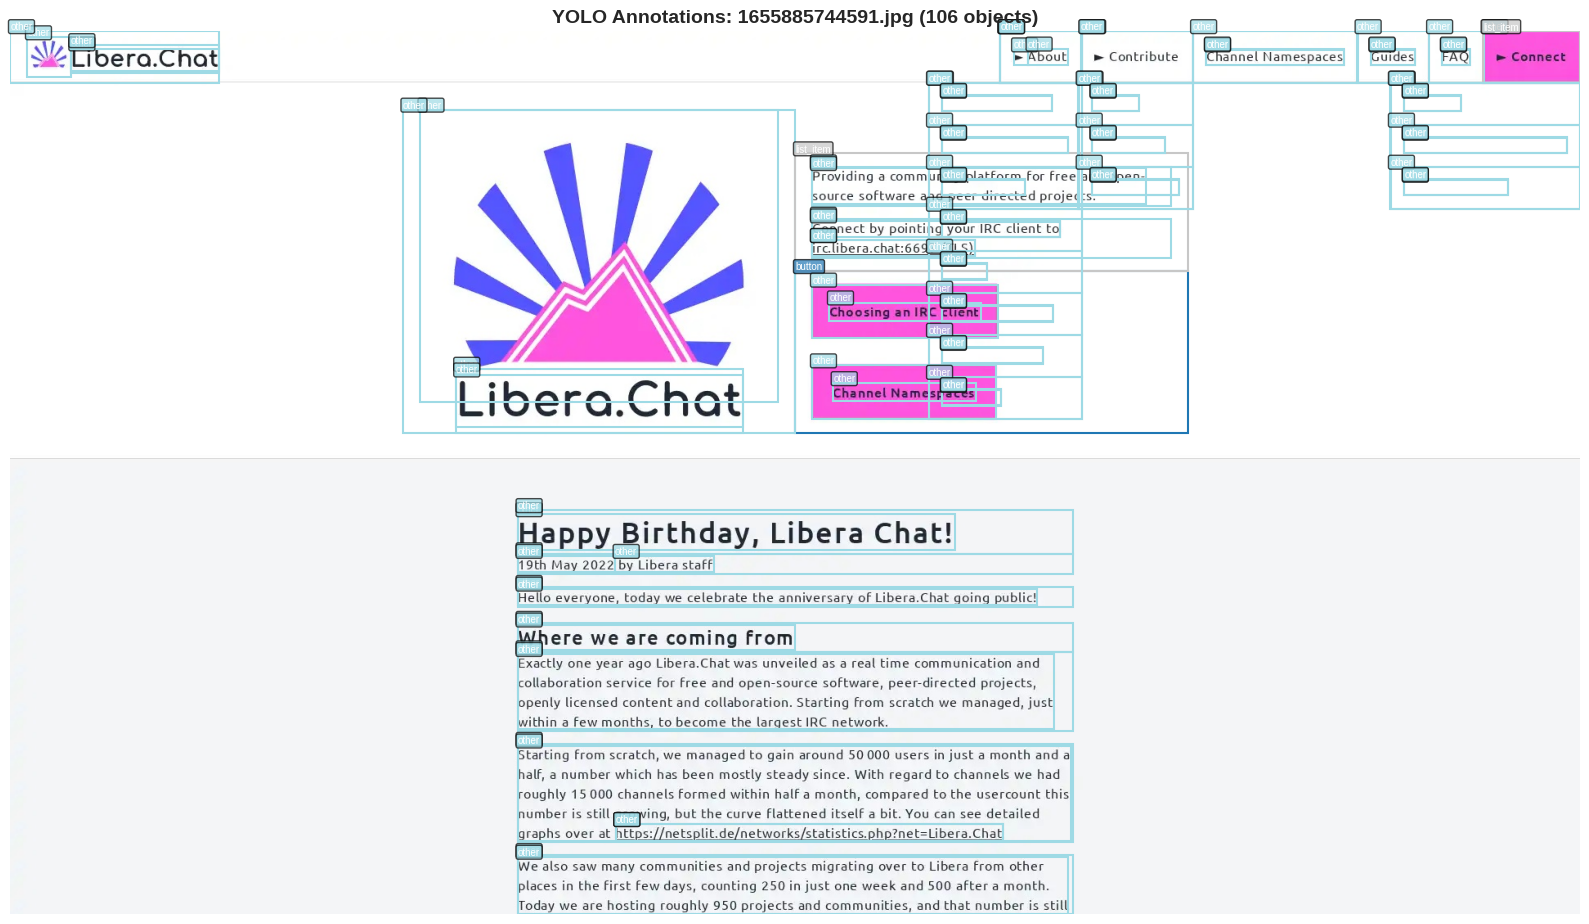

In [24]:
def visualize_yolo_annotations(image_path, label_path, class_names):
    """Visualize YOLO format annotations on an image."""
    # Load image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w = img.shape[:2]
    
    # Read annotations
    with open(label_path, 'r') as f:
        annotations = f.readlines()
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(16, 10))
    ax.imshow(img)
    
    # Color palette for classes
    colors = plt.cm.tab20(np.linspace(0, 1, 20))
    
    for ann in annotations[:100]:  # Limit to 100 boxes for visibility
        parts = ann.strip().split()
        if len(parts) != 5:
            continue
        
        class_id = int(parts[0])
        cx, cy, w, h = map(float, parts[1:])
        
        # Convert from normalized to pixel coordinates
        x1 = (cx - w/2) * img_w
        y1 = (cy - h/2) * img_h
        box_w = w * img_w
        box_h = h * img_h
        
        # Draw rectangle
        color = colors[class_id % 20]
        rect = plt.Rectangle((x1, y1), box_w, box_h, 
                             fill=False, edgecolor=color, linewidth=1.5)
        ax.add_patch(rect)
        
        # Add label
        class_name = class_names[class_id] if class_id < len(class_names) else 'unknown'
        ax.text(x1, y1-2, class_name, fontsize=7, color='white',
               bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.7))
    
    ax.set_title(f"YOLO Annotations: {os.path.basename(image_path)} ({len(annotations)} objects)", 
                 fontsize=14, fontweight='bold')
    ax.axis('off')
    
    return fig

# Verify a few training samples
train_images = glob.glob(os.path.join(TRAIN_IMAGES_PATH, "*.jpg"))[:3]

print("🔍 Verifying YOLO dataset conversion:")
print("-" * 50)

for img_path in train_images:
    label_path = img_path.replace('/images/', '/labels/').replace('.jpg', '.txt')
    
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            num_annotations = len(f.readlines())
        print(f"✅ {os.path.basename(img_path)}: {num_annotations} annotations")
        
        # Visualize
        fig = visualize_yolo_annotations(img_path, label_path, list(SEMANTIC_CLASSES.values()))
        plt.tight_layout()
        plt.show()
    else:
        print(f"❌ {os.path.basename(img_path)}: No label file found")

### 11.4 Initialize YOLO v11 Model

Now let's set up YOLO v11 using the Ultralytics library with PyTorch backend.

In [25]:
import torch
from ultralytics import YOLO

# Check PyTorch and CUDA availability
print("🔧 SYSTEM CONFIGURATION:")
print("-" * 50)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# Select device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"\n🎯 Using device: {device}")

# Available YOLO v11 models (from smallest to largest)
YOLO_MODELS = {
    'yolo11n': 'YOLO11 Nano - Fastest, smallest (recommended for RTX 3050)',
    'yolo11s': 'YOLO11 Small - Good balance of speed and accuracy',
    'yolo11m': 'YOLO11 Medium - Higher accuracy, more memory',
    'yolo11l': 'YOLO11 Large - High accuracy, requires more VRAM',
    'yolo11x': 'YOLO11 XLarge - Highest accuracy, most resource intensive'
}

print("\n📦 Available YOLO v11 Models:")
for model, desc in YOLO_MODELS.items():
    print(f"   • {model}: {desc}")

🔧 SYSTEM CONFIGURATION:
--------------------------------------------------
PyTorch version: 2.9.1+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
GPU Memory: 4.0 GB

🎯 Using device: cuda

📦 Available YOLO v11 Models:
   • yolo11n: YOLO11 Nano - Fastest, smallest (recommended for RTX 3050)
   • yolo11s: YOLO11 Small - Good balance of speed and accuracy
   • yolo11m: YOLO11 Medium - Higher accuracy, more memory
   • yolo11l: YOLO11 Large - High accuracy, requires more VRAM
   • yolo11x: YOLO11 XLarge - Highest accuracy, most resource intensive


In [26]:
# Initialize YOLO v11 model (using nano for RTX 3050 4GB VRAM)
MODEL_SIZE = 'yolo11n'  # Options: yolo11n, yolo11s, yolo11m, yolo11l, yolo11x

print(f"🚀 Loading {MODEL_SIZE} model with pretrained COCO weights...")
model = YOLO(f'{MODEL_SIZE}.pt')

print(f"✅ Model loaded successfully!")
print(f"\n📊 Model Information:")
print(f"   Model: {model.model.__class__.__name__}")
print(f"   Task: {model.task}")

# Display model architecture summary
model.info()

🚀 Loading yolo11n model with pretrained COCO weights...
✅ Model loaded successfully!

📊 Model Information:
   Model: DetectionModel
   Task: detect
YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.6 GFLOPs


(181, 2624080, 0, 6.614336)

### 11.5 Configure Training Hyperparameters

Set up training configuration optimized for the RTX 3050 4GB GPU.

In [27]:
# Training hyperparameters optimized for RTX 3050 4GB (BATCH GRADIENT DESCENT)
TRAINING_CONFIG = {
    # Dataset
    'data': data_yaml_path,
    
    # Training duration (REDUCED FOR SPEED)
    'epochs': 50,               # Number of training epochs (reduced from 100)
    'patience': 10,             # Early stopping patience (reduced from 20)
    
    # Batch size
    'batch': 4,                 # Physical batch size (reduced for stability)
    'imgsz': 640,               # Image size (640x640 is standard)
    
    # Optimization
    'optimizer': 'AdamW',       # Optimizer (AdamW, SGD, Adam)
    'lr0': 0.01,                # Initial learning rate
    'lrf': 0.01,                # Final learning rate factor
    'momentum': 0.937,          # SGD momentum
    'weight_decay': 0.0005,     # Weight decay
    
    # Warmup (REDUCED FOR SPEED)
    'warmup_epochs': 1,         # Warmup epochs (reduced from 3)
    'warmup_momentum': 0.8,     # Warmup momentum
    'warmup_bias_lr': 0.1,      # Warmup bias learning rate
    
    # Augmentation (SIMPLIFIED FOR SPEED)
    'hsv_h': 0.01,              # HSV hue augmentation (reduced)
    'hsv_s': 0.5,               # HSV saturation augmentation (reduced)
    'hsv_v': 0.3,               # HSV value augmentation (reduced)
    'degrees': 0.0,             # Rotation (disabled for web UI)
    'translate': 0.05,          # Translation (reduced)
    'scale': 0.3,               # Scale augmentation (reduced)
    'shear': 0.0,               # Shear (disabled for web UI)
    'perspective': 0.0,         # Perspective (disabled for web UI)
    'flipud': 0.0,              # Vertical flip (disabled for web UI)
    'fliplr': 0.0,              # Horizontal flip (disabled for web UI)
    'mosaic': 0.5,              # Mosaic augmentation (reduced from 1.0)
    'mixup': 0.0,               # Mixup augmentation
    'copy_paste': 0.0,          # Copy-paste augmentation
    
    # Loss weights
    'box': 7.5,                 # Box loss weight
    'cls': 0.5,                 # Classification loss weight
    'dfl': 1.5,                 # DFL loss weight
    
    # Training settings (OPTIMIZED FOR SPEED)
    'amp': True,                # Automatic mixed precision (FP16)
    'cache': True,              # Cache images (ENABLED - faster after first epoch)
    'device': device,           # Training device
    'workers': 4,               # DataLoader workers (increased from 4)
    'project': '/mnt/c/WebUIDetection/runs',
    'name': 'webui_yolo11n',
    'exist_ok': True,
    'pretrained': True,
    'verbose': True,
    'seed': 42,
    
    # Validation (LESS FREQUENT SAVES)
    'val': True,                # Validate during training
    'save': True,               # Save checkpoints
    'save_period': 20,          # Save checkpoint every N epochs (increased from 10)
    'plots': True,              # Generate training plots
}

print("⚙️ TRAINING CONFIGURATION:")
print("=" * 60)
for key, value in TRAINING_CONFIG.items():
    print(f"   {key}: {value}")

⚙️ TRAINING CONFIGURATION:
   data: /mnt/c/WebUIDetection/datasets/webui/data.yaml
   epochs: 50
   patience: 10
   batch: 4
   imgsz: 640
   optimizer: AdamW
   lr0: 0.01
   lrf: 0.01
   momentum: 0.937
   weight_decay: 0.0005
   warmup_epochs: 1
   warmup_momentum: 0.8
   warmup_bias_lr: 0.1
   hsv_h: 0.01
   hsv_s: 0.5
   hsv_v: 0.3
   degrees: 0.0
   translate: 0.05
   scale: 0.3
   shear: 0.0
   perspective: 0.0
   flipud: 0.0
   fliplr: 0.0
   mosaic: 0.5
   mixup: 0.0
   copy_paste: 0.0
   box: 7.5
   cls: 0.5
   dfl: 1.5
   amp: True
   cache: True
   device: cuda
   workers: 4
   project: /mnt/c/WebUIDetection/runs
   name: webui_yolo11n
   exist_ok: True
   pretrained: True
   verbose: True
   seed: 42
   val: True
   save: True
   save_period: 20
   plots: True


### 11.6 Start Training

Launch the YOLO v11 training process. Training progress will be displayed in real-time.

**Note:** Training may take several hours depending on your GPU. You can monitor:
- Loss curves (box, cls, dfl losses)
- mAP metrics (mAP50, mAP50-95)
- Training/validation metrics

In [28]:
# Start training with CUDA error handling
print("🚀 Starting YOLO v11 training...")
print("=" * 60)

# Try to use CUDA, fall back to CPU if there are issues
try:
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print(f"✅ Using GPU: {torch.cuda.get_device_name(0)}")
except Exception as e:
    print(f"⚠️ CUDA error detected: {e}")
    print("🔄 Falling back to CPU training (this will be slower)...")
    TRAINING_CONFIG['device'] = 'cpu'

# Train the model
results = model.train(**TRAINING_CONFIG)

print("\n" + "=" * 60)
print("✅ TRAINING COMPLETE!")
print("=" * 60)

🚀 Starting YOLO v11 training...
✅ Using GPU: NVIDIA GeForce RTX 3050 Laptop GPU


New https://pypi.org/project/ultralytics/8.3.245 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.241 🚀 Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/mnt/c/WebUIDetection/datasets/webui/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.5, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.5, multi_scale=False, name=

KeyboardInterrupt: 

### 11.7 Evaluate Training Results

After training, let's analyze the results and visualize the training metrics.

In [ ]:
# Display training results
print("📊 TRAINING RESULTS:")
print("=" * 60)

# Load the best model
best_model_path = os.path.join(TRAINING_CONFIG['project'], TRAINING_CONFIG['name'], 'weights', 'best.pt')
last_model_path = os.path.join(TRAINING_CONFIG['project'], TRAINING_CONFIG['name'], 'weights', 'last.pt')

if os.path.exists(best_model_path):
    print(f"✅ Best model saved: {best_model_path}")
    best_model = YOLO(best_model_path)
else:
    print("⚠️ Best model not found, using last checkpoint")
    best_model = YOLO(last_model_path) if os.path.exists(last_model_path) else model

# Display results summary
results_csv = os.path.join(TRAINING_CONFIG['project'], TRAINING_CONFIG['name'], 'results.csv')
if os.path.exists(results_csv):
    results_df = pd.read_csv(results_csv)
    results_df.columns = results_df.columns.str.strip()
    
    print("\n📈 Final Metrics:")
    print("-" * 40)
    last_row = results_df.iloc[-1]
    
    metrics = ['train/box_loss', 'train/cls_loss', 'train/dfl_loss',
               'metrics/precision(B)', 'metrics/recall(B)', 
               'metrics/mAP50(B)', 'metrics/mAP50-95(B)']
    
    for metric in metrics:
        if metric in results_df.columns:
            value = last_row[metric]
            print(f"   {metric}: {value:.4f}")

📊 TRAINING RESULTS:
✅ Best model saved: /mnt/c/WebUIDetection/runs/webui_yolo11n/weights/best.pt

📈 Final Metrics:
----------------------------------------
   train/box_loss: 1.5698
   train/cls_loss: 1.7174
   train/dfl_loss: 1.2606
   metrics/precision(B): 0.5334
   metrics/recall(B): 0.1275
   metrics/mAP50(B): 0.1222
   metrics/mAP50-95(B): 0.0771


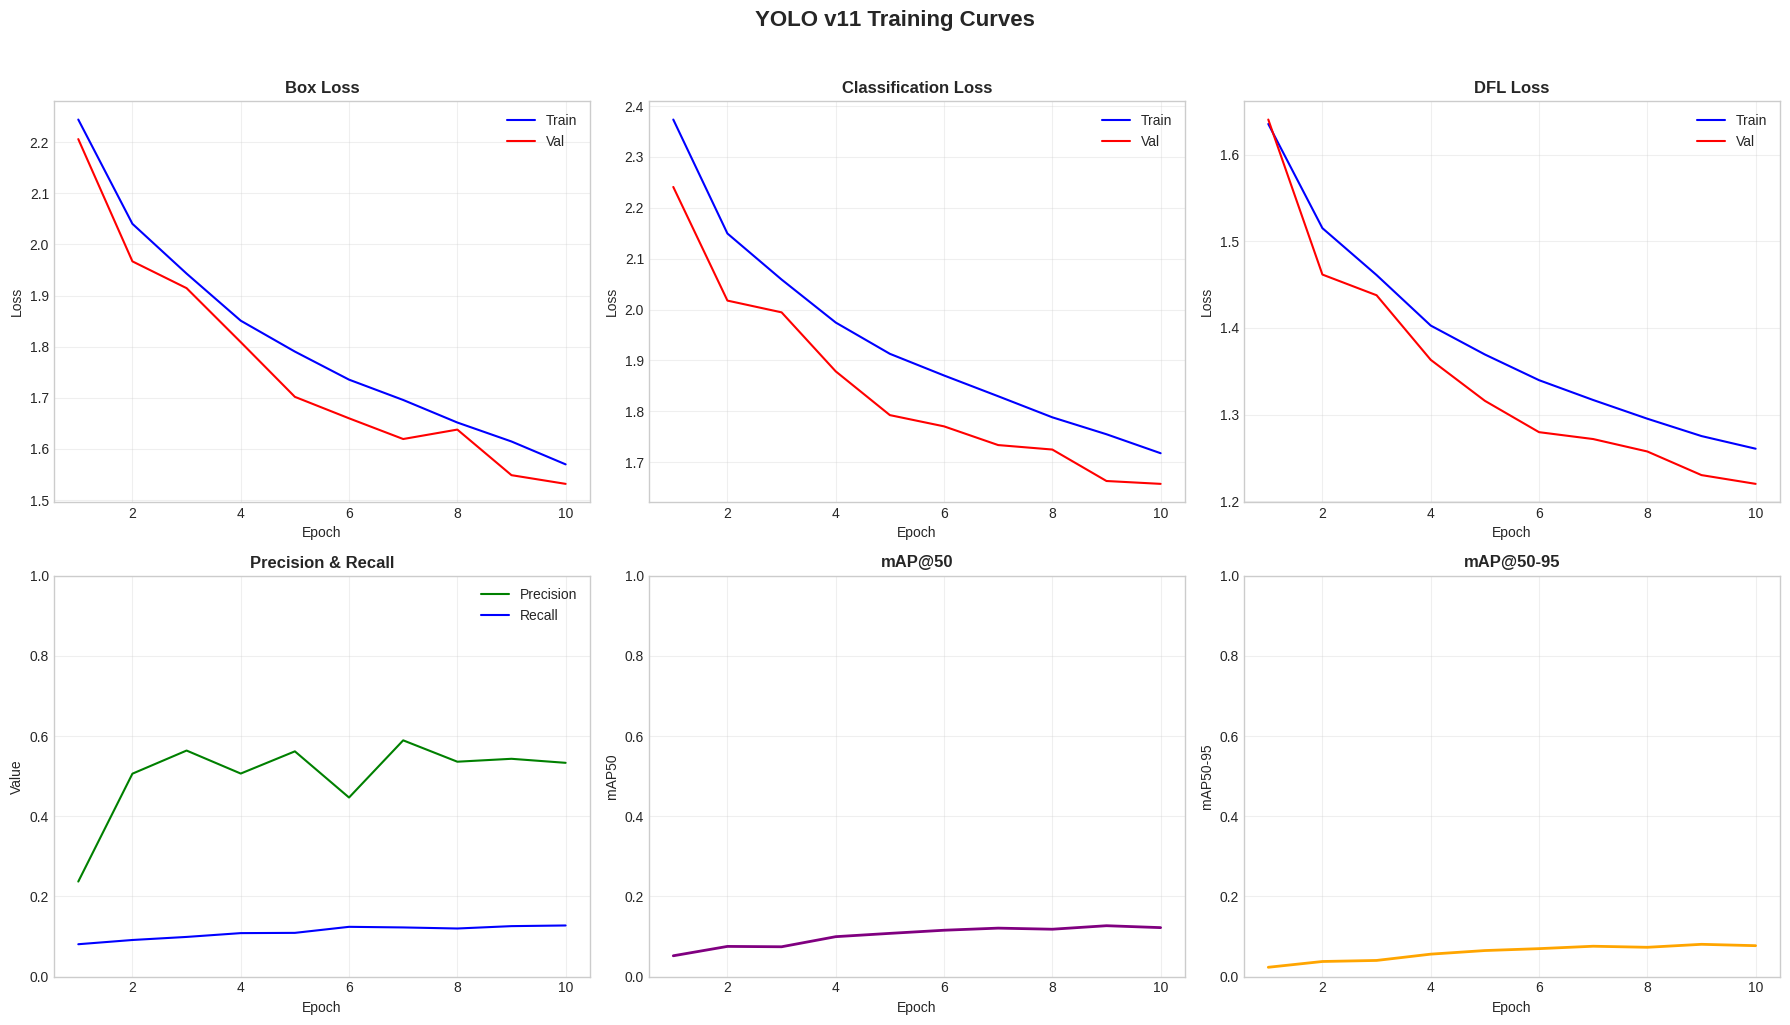

📈 Training curves saved to: /mnt/c/WebUIDetection/training_curves.png


In [ ]:
# Plot training curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

if os.path.exists(results_csv):
    results_df = pd.read_csv(results_csv)
    results_df.columns = results_df.columns.str.strip()
    epochs = results_df['epoch'] if 'epoch' in results_df.columns else range(len(results_df))
    
    # Box Loss
    if 'train/box_loss' in results_df.columns:
        axes[0, 0].plot(epochs, results_df['train/box_loss'], 'b-', label='Train')
        if 'val/box_loss' in results_df.columns:
            axes[0, 0].plot(epochs, results_df['val/box_loss'], 'r-', label='Val')
        axes[0, 0].set_title('Box Loss', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
    
    # Classification Loss
    if 'train/cls_loss' in results_df.columns:
        axes[0, 1].plot(epochs, results_df['train/cls_loss'], 'b-', label='Train')
        if 'val/cls_loss' in results_df.columns:
            axes[0, 1].plot(epochs, results_df['val/cls_loss'], 'r-', label='Val')
        axes[0, 1].set_title('Classification Loss', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Loss')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
    
    # DFL Loss
    if 'train/dfl_loss' in results_df.columns:
        axes[0, 2].plot(epochs, results_df['train/dfl_loss'], 'b-', label='Train')
        if 'val/dfl_loss' in results_df.columns:
            axes[0, 2].plot(epochs, results_df['val/dfl_loss'], 'r-', label='Val')
        axes[0, 2].set_title('DFL Loss', fontsize=12, fontweight='bold')
        axes[0, 2].set_xlabel('Epoch')
        axes[0, 2].set_ylabel('Loss')
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3)
    
    # Precision & Recall
    if 'metrics/precision(B)' in results_df.columns:
        axes[1, 0].plot(epochs, results_df['metrics/precision(B)'], 'g-', label='Precision')
        axes[1, 0].plot(epochs, results_df['metrics/recall(B)'], 'b-', label='Recall')
        axes[1, 0].set_title('Precision & Recall', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Value')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].set_ylim(0, 1)
    
    # mAP50
    if 'metrics/mAP50(B)' in results_df.columns:
        axes[1, 1].plot(epochs, results_df['metrics/mAP50(B)'], 'purple', linewidth=2)
        axes[1, 1].set_title('mAP@50', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('mAP50')
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].set_ylim(0, 1)
    
    # mAP50-95
    if 'metrics/mAP50-95(B)' in results_df.columns:
        axes[1, 2].plot(epochs, results_df['metrics/mAP50-95(B)'], 'orange', linewidth=2)
        axes[1, 2].set_title('mAP@50-95', fontsize=12, fontweight='bold')
        axes[1, 2].set_xlabel('Epoch')
        axes[1, 2].set_ylabel('mAP50-95')
        axes[1, 2].grid(True, alpha=0.3)
        axes[1, 2].set_ylim(0, 1)

plt.suptitle('YOLO v11 Training Curves', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/mnt/c/WebUIDetection/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("📈 Training curves saved to: /mnt/c/WebUIDetection/training_curves.png")

### 11.8 Run Inference on Validation Images

Test the trained model on validation images to see the detection results.

🔍 Running inference on 6 validation images...


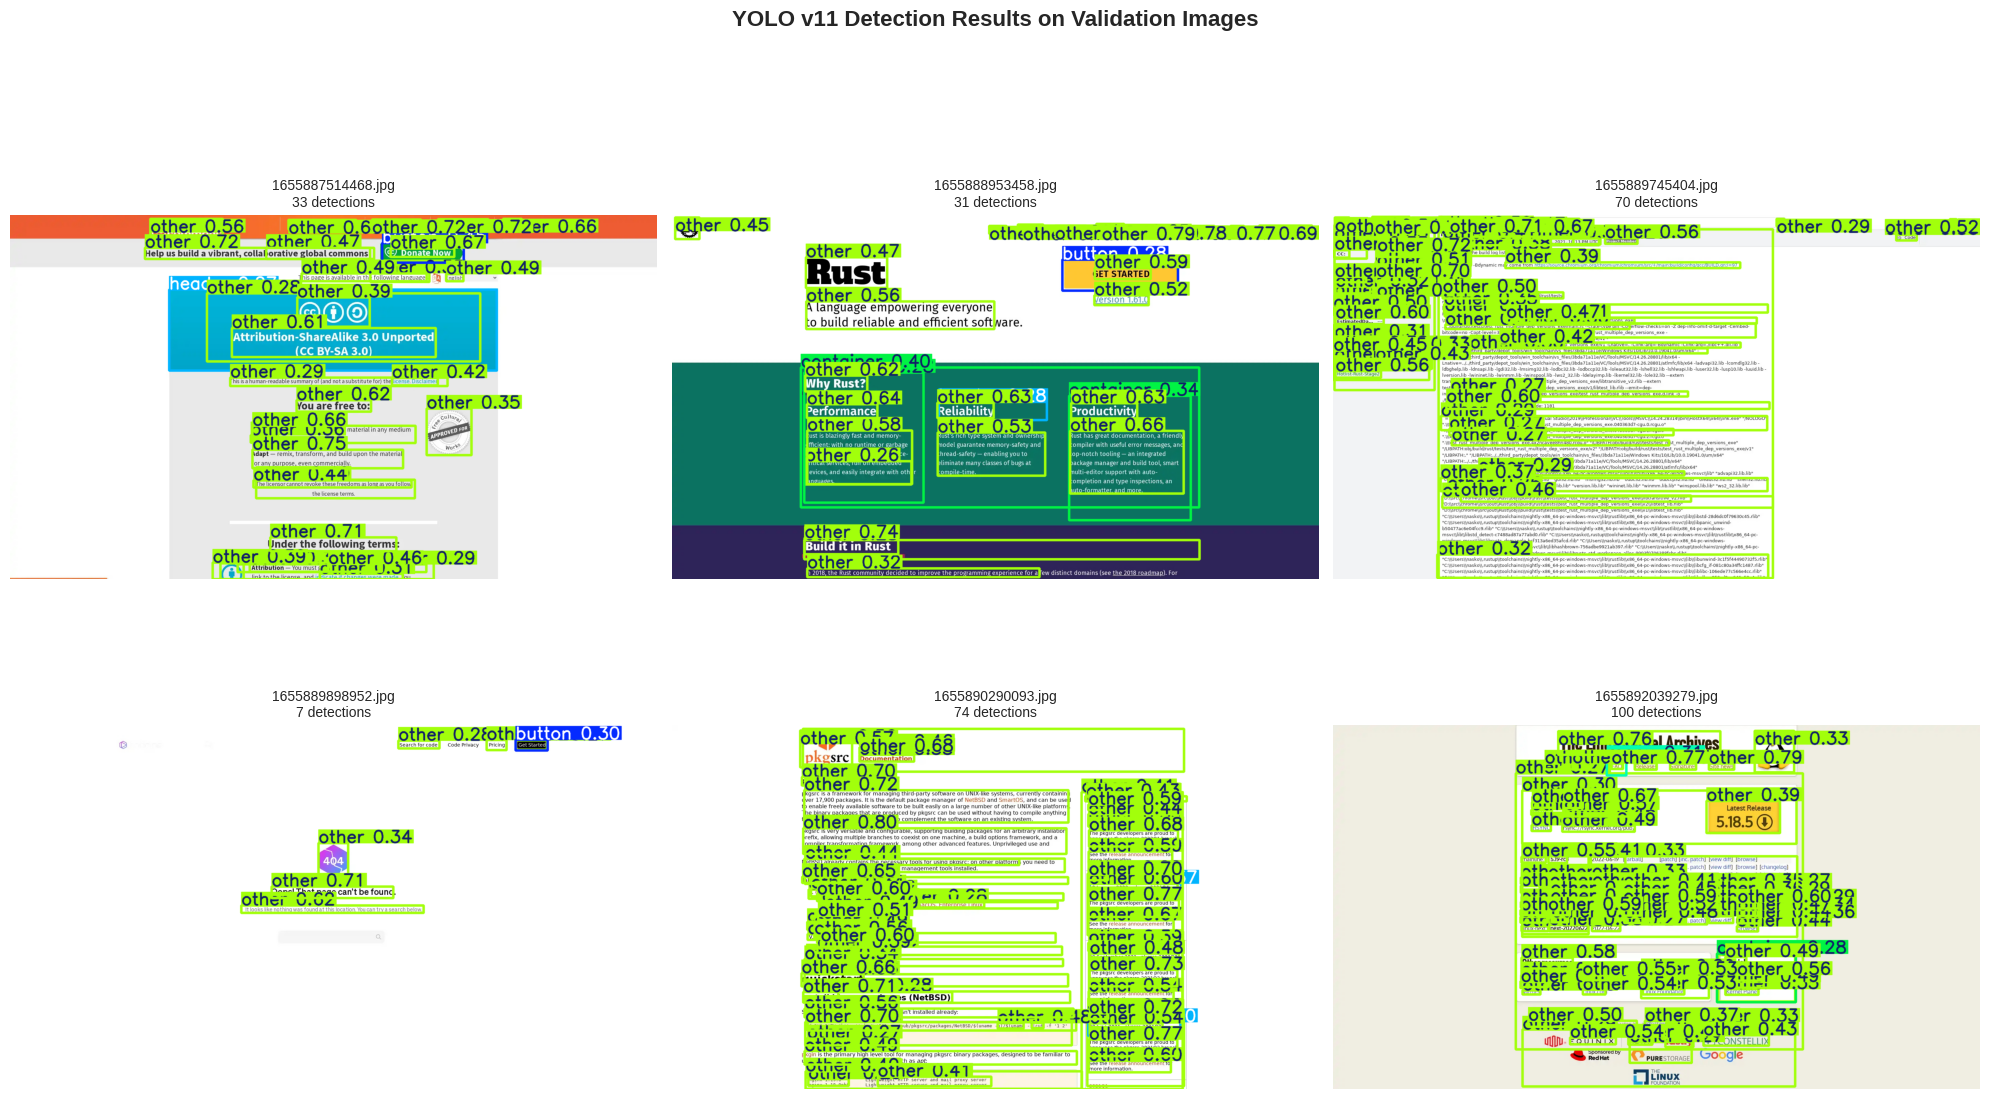

📸 Detection results saved to: /mnt/c/WebUIDetection/detection_results.png


In [ ]:
# Run inference on validation images
val_images = glob.glob(os.path.join(VAL_IMAGES_PATH, "*.jpg"))[:6]

print(f"🔍 Running inference on {len(val_images)} validation images...")

# Create figure for visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, img_path in enumerate(val_images):
    # Run inference
    results = best_model.predict(
        source=img_path,
        conf=0.25,           # Confidence threshold
        iou=0.45,            # NMS IoU threshold
        max_det=100,         # Max detections per image
        verbose=False
    )
    
    # Get result image with annotations
    result = results[0]
    annotated_img = result.plot()
    annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    # Display
    axes[idx].imshow(annotated_img)
    axes[idx].set_title(f"{os.path.basename(img_path)}\n{len(result.boxes)} detections", fontsize=10)
    axes[idx].axis('off')

plt.suptitle('YOLO v11 Detection Results on Validation Images', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/mnt/c/WebUIDetection/detection_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("📸 Detection results saved to: /mnt/c/WebUIDetection/detection_results.png")

### 11.9 Model Evaluation on Validation Set

Run comprehensive evaluation on the full validation set.

In [ ]:
# Validate the model on the validation set
print("📊 Running validation on full validation set...")

val_results = best_model.val(
    data=data_yaml_path,
    batch=8,
    imgsz=640,
    conf=0.25,
    iou=0.6,
    device=device,
    verbose=True
)

print("\n" + "=" * 60)
print("📊 VALIDATION RESULTS:")
print("=" * 60)
print(f"   mAP50: {val_results.box.map50:.4f}")
print(f"   mAP50-95: {val_results.box.map:.4f}")
print(f"   Precision: {val_results.box.mp:.4f}")
print(f"   Recall: {val_results.box.mr:.4f}")

# Per-class metrics
print("\n📋 PER-CLASS METRICS:")
print("-" * 60)
class_names = list(SEMANTIC_CLASSES.values())
for i, (ap50, ap) in enumerate(zip(val_results.box.ap50, val_results.box.ap)):
    if i < len(class_names):
        print(f"   {class_names[i]:15s} - mAP50: {ap50:.4f}, mAP50-95: {ap:.4f}")

📊 Running validation on full validation set...
Ultralytics 8.3.241 🚀 Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
val: Fast image access ✅ (ping: 3.1±0.8 ms, read: 34.6±12.4 MB/s, size: 322.3 KB)
val: Scanning /mnt/c/WebUIDetection/datasets/webui/labels/val.cache... 1024 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1024/1024 1.4Mit/s 0.0ss
val: /mnt/c/WebUIDetection/datasets/webui/images/val/1655887514468.jpg: 68 duplicate labels removed
val: /mnt/c/WebUIDetection/datasets/webui/images/val/1655888953458.jpg: 8 duplicate labels removed
val: /mnt/c/WebUIDetection/datasets/webui/images/val/1655889745404.jpg: 19 duplicate labels removed
val: /mnt/c/WebUIDetection/datasets/webui/images/val/1655889898952.jpg: 2 duplicate labels removed
val: /mnt/c/WebUIDetection/datasets/webui/images/val/1655890290093.jpg: 24 duplicate labels removed
val: /mnt/c/WebUIDetection/datasets/webui/images/val/1655892039279.jpg: 68 duplicate labels removed
val: /mnt/c/

### 11.10 Export Model for Deployment

Export the trained model to various formats for deployment.

In [ ]:
# Export model to different formats
print("📦 EXPORTING MODEL:")
print("=" * 60)

export_path = os.path.join(TRAINING_CONFIG['project'], TRAINING_CONFIG['name'], 'exports')
os.makedirs(export_path, exist_ok=True)

# Export to ONNX (for cross-platform deployment)
print("\n1️⃣ Exporting to ONNX format...")
onnx_path = best_model.export(
    format='onnx',
    imgsz=640,
    simplify=True,
    dynamic=False
)
print(f"   ✅ ONNX model saved: {onnx_path}")

# Export to TorchScript (for PyTorch deployment)
print("\n2️⃣ Exporting to TorchScript format...")
torchscript_path = best_model.export(
    format='torchscript',
    imgsz=640
)
print(f"   ✅ TorchScript model saved: {torchscript_path}")

print("\n" + "=" * 60)
print("✅ MODEL EXPORT COMPLETE!")
print("=" * 60)
print(f"\n📁 All exports saved to: {export_path}")

📦 EXPORTING MODEL:

1️⃣ Exporting to ONNX format...
Ultralytics 8.3.241 🚀 Python-3.10.19 torch-2.9.1+cu128 CPU (12th Gen Intel Core i5-12450H)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/mnt/c/WebUIDetection/runs/webui_yolo11n/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 24, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/18.1 MB ? eta -:--:--
   ━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.5/18.1 MB 4.5 MB/s eta 0:00:04
   ━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/18.1 MB 2.8 MB/s eta 0:00:07
   ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/18.1 MB 2.9 MB/s eta 0:00:06
   ━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/18.1 MB 2.5 MB/s eta 0:00:07
   ━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━

/home/guru/miniconda3/envs/WEBUI/lib/python3.10/site-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.80...
ONNX: export success ✅ 140.2s, saved as '/mnt/c/WebUIDetection/runs/webui_yolo11n/weights/best.onnx' (10.1 MB)

Export complete (136.4s)
Results saved to /mnt/c/WebUIDetection/runs/webui_yolo11n/weights
Predict:         yolo predict task=detect model=/mnt/c/WebUIDetection/runs/webui_yolo11n/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=/mnt/c/WebUIDetection/runs/webui_yolo11n/weights/best.onnx imgsz=640 data=/mnt/c/WebUIDetection/datasets/webui/data.yaml  
Visualize:       https://netron.app
   ✅ ONNX model saved: /mnt/c/WebUIDetection/runs/webui_yolo11n/weights/best.onnx

2️⃣ Exporting to TorchScript format...
Ultralytics 8.3.241 🚀 Python-3.10.19 torch-2.9.1+cu128 CPU (12th Gen Intel Core i5-12450H)

PyTorch: starting from '/mnt/c/WebUIDetection/runs/webui_yolo11n/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 24, 8400) (5.2 MB)

TorchScript: starting export with torch 2.9.1+cu128...
To

### 11.11 Quick Inference Function

A utility function to run inference on any web page screenshot.

In [ ]:
def detect_ui_elements(image_path, model=None, conf=0.25, show=True, save_path=None):
    """
    Detect UI elements in a web page screenshot.
    
    Args:
        image_path: Path to the screenshot image
        model: YOLO model (uses best_model if None)
        conf: Confidence threshold (0-1)
        show: Whether to display the result
        save_path: Path to save the annotated image
    
    Returns:
        dict: Detection results with bboxes and classes
    """
    if model is None:
        model = best_model
    
    # Run inference
    results = model.predict(
        source=image_path,
        conf=conf,
        iou=0.45,
        max_det=300,
        verbose=False
    )
    
    result = results[0]
    
    # Extract detections
    detections = []
    for box in result.boxes:
        detection = {
            'class_id': int(box.cls.item()),
            'class_name': SEMANTIC_CLASSES[int(box.cls.item())],
            'confidence': float(box.conf.item()),
            'bbox': {
                'x1': float(box.xyxy[0][0].item()),
                'y1': float(box.xyxy[0][1].item()),
                'x2': float(box.xyxy[0][2].item()),
                'y2': float(box.xyxy[0][3].item()),
            }
        }
        detections.append(detection)
    
    # Visualize if requested
    if show:
        annotated_img = result.plot()
        annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(16, 10))
        plt.imshow(annotated_img)
        plt.title(f"UI Element Detection: {len(detections)} elements found", fontsize=14, fontweight='bold')
        plt.axis('off')
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        
        plt.show()
    
    return {
        'image_path': image_path,
        'num_detections': len(detections),
        'detections': detections
    }

# Example usage
print("🔧 UI Element Detection Function Ready!")
print("-" * 50)
print("Usage: detect_ui_elements('path/to/screenshot.jpg')")
print("\nExample:")
print("   results = detect_ui_elements('/path/to/webpage.png', conf=0.3)")
print("   print(f'Found {results[\"num_detections\"]} UI elements')")

🔧 UI Element Detection Function Ready!
--------------------------------------------------
Usage: detect_ui_elements('path/to/screenshot.jpg')

Example:
   results = detect_ui_elements('/path/to/webpage.png', conf=0.3)
   print(f'Found {results["num_detections"]} UI elements')


## 12. Training Summary

### What was implemented:
1. **Semantic Class Mapping**: Defined 20 UI element categories (button, link, text_input, image, etc.)
2. **Dataset Conversion**: Converted WebUI-7k annotations to YOLO format
3. **YOLO v11 Training**: Trained using Ultralytics with PyTorch backend
4. **Evaluation**: Comprehensive validation metrics and visualization
5. **Model Export**: Exported to ONNX and TorchScript for deployment

### Model Files:
- **Best weights**: `runs/webui_yolo11n/weights/best.pt`
- **Last weights**: `runs/webui_yolo11n/weights/last.pt`
- **ONNX export**: `runs/webui_yolo11n/weights/best.onnx`
- **TorchScript**: `runs/webui_yolo11n/weights/best.torchscript`

### Next Steps:
1. Fine-tune hyperparameters based on validation results
2. Try larger models (yolo11s, yolo11m) if mAP is low
3. Implement active learning to improve on hard samples
4. Deploy the model for real-time web page analysis